# IMDb Sentiment Classification with 14 BERT-Family Models

This beginner-friendly notebook downloads and preprocesses the **IMDb Dataset of 50K Movie Reviews**, explores it with charts and word clouds, and then trains and compares:

1. BERT-base
2. mBERT (Multilingual BERT)
3. XLM-RoBERTa-base
4. mDeBERTa-v3-base
5. RemBERT
6. ALBERT-base
7. DistilBERT
8. TinyBERT
9. DeBERTa-v2
10. ModernBERT-base
11. RoBERTa-base
12. IndicBERT v2
13. MuRIL
14. ELECTRA-base

The notebook automatically retains **only the best-performing model** for deployment, packages it as a ZIP file, and provides a Colab download button.

## What you will learn

- How to inspect and clean a text dataset
- Why Transformer preprocessing differs from traditional NLP preprocessing
- How tokenization and dynamic padding work
- How to fine-tune sequence-classification models with Hugging Face `Trainer`
- How to calculate accuracy, precision, recall, F1-score, ROC-AUC and confusion matrices
- How to compare performance, loss, runtime, model size and efficiency using graphs
- How to save, test and download the best model for deployment

> **Important:** The IMDb reviews are English. Multilingual models can still be fine-tuned on them, but this experiment does **not** measure multilingual ability. For a real multilingual comparison, use the same models later on English + Hindi + Bengali reviews.


## Before running

In Google Colab, choose **Runtime → Change runtime type → GPU**.

The notebook has two modes:

- `RUN_MODE = "quick"`: uses a stratified subset and 128 tokens. Start here.
- `RUN_MODE = "full"`: uses the complete cleaned dataset and 256 tokens. This can take many GPU-hours for all models.

### Special handling for the large models

- **mDeBERTa-v3-base** uses full fine-tuning, but gradient checkpointing is disabled because that path caused the earlier `Trying to backward through the graph a second time` error.
- **RemBERT** and **DeBERTa-v2 xlarge** are very large. In the default `TRAINING_STRATEGY = "memory_safe"` mode, their encoders are frozen and only their classification heads are trained. Their results are marked `head_only` and must be discussed separately from fully fine-tuned results.
- DeBERTa-v2 has no official base-size checkpoint in this family, so `microsoft/deberta-v2-xlarge` is used. It has about 900 million parameters and can still require substantial RAM even in head-only mode.

The best model is selected by **F1-score**, with **ROC-AUC** and **accuracy** used as tie-breakers. Only the winning model is retained, which avoids storing all 14 checkpoints.


## Step 1 — Install the required libraries


**Code explanation:** Installs every required Python package inside the current notebook runtime. `subprocess.check_call` uses the same Python interpreter as the notebook, which avoids installing libraries into a different environment.


In [1]:
import sys
import subprocess

packages = [
    "transformers>=4.48.0,<5.0.0",
    "datasets>=3.2.0,<4.0.0",
    "accelerate>=1.2.0,<2.0.0",
    "evaluate>=0.4.3",
    "sentencepiece>=0.2.0",
    "protobuf>=4.25.0",
    "scikit-learn>=1.4.0",
    "pandas>=2.0.0",
    "numpy>=1.26.0",
    "matplotlib>=3.8.0",
    "seaborn>=0.13.0",
    "wordcloud>=1.9.3",
    "beautifulsoup4>=4.12.0",
    "kagglehub>=0.3.0",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("Installation complete. If Colab asks for a restart, restart the runtime once.")


Installation complete. If Colab asks for a restart, restart the runtime once.


## Step 2 — Import libraries and set a random seed


**Code explanation:** Imports the data, visualization, machine-learning and Transformer libraries; sets a fixed random seed; and reports whether a CUDA GPU is available. Fixing the seed improves reproducibility, although GPU training may still have small numerical variations.


In [2]:
import gc
import html
import json
import os
import random
import re
import shutil
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from bs4 import BeautifulSoup
from datasets import Dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print("WARNING: No GPU detected. Training all models on CPU is not practical.")


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 15.64


## Step 3 — Download/load the Kaggle dataset

The loader checks common Kaggle and Colab paths first. If it cannot find the CSV, it downloads the public dataset using `kagglehub`.

Expected columns:

- `review`: movie-review text
- `sentiment`: `positive` or `negative`


**Code explanation:** Searches common Colab and Kaggle paths for `IMDB Dataset.csv`. If the file is absent, it downloads the public Kaggle dataset and loads it into a Pandas DataFrame named `df_raw`.


In [3]:
import kagglehub

DATASET_HANDLE = "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
COMMON_PATHS = [
    Path("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"),
    Path("/content/IMDB Dataset.csv"),
    Path("IMDB Dataset.csv"),
]

csv_path = next((p for p in COMMON_PATHS if p.exists()), None)

if csv_path is None:
    downloaded_dir = Path(kagglehub.dataset_download(DATASET_HANDLE))
    matches = list(downloaded_dir.rglob("IMDB Dataset.csv"))
    if not matches:
        matches = list(downloaded_dir.rglob("*.csv"))
    if not matches:
        raise FileNotFoundError("No CSV file was found after downloading the Kaggle dataset.")
    csv_path = matches[0]

print("Dataset file:", csv_path)
df_raw = pd.read_csv(csv_path)
print("Raw shape:", df_raw.shape)
df_raw.head()


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset file: /kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
Raw shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Step 4 — Initial inspection


**Code explanation:** Inspects the raw table before changing it. It reports dimensions, column names, data types, missing values, duplicate rows and the number of positive and negative labels.


In [4]:
print("Rows and columns:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df_raw.isna().sum().to_frame("missing_count"))

print("\nExact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate review texts:", df_raw.duplicated(subset=["review"]).sum())

print("\nSentiment counts:")
display(df_raw["sentiment"].value_counts(dropna=False).to_frame("count"))


Rows and columns: (50000, 2)

Column names: ['review', 'sentiment']

Data types:


,dtype
review,object
sentiment,object



Missing values:


,missing_count
review,0
sentiment,0



Exact duplicate rows: 418
Duplicate review texts: 418

Sentiment counts:


,count
sentiment,
positive,25000
negative,25000


## Step 5 — Clean and encode the reviews

For Transformer models, avoid aggressive preprocessing. We remove HTML tags, URLs, extra spaces, missing rows and duplicate reviews, but we **keep punctuation, word order and stopwords** because they contain useful context. We also preserve letter case because several requested tokenizers are cased.


**Code explanation:** Performs light Transformer-friendly cleaning: decoding HTML entities, removing HTML tags and URLs, normalizing whitespace, dropping invalid/duplicate rows and encoding negative as 0 and positive as 1. Stopwords and punctuation are retained because context matters to BERT-family models.


In [5]:
def clean_review(text):
    # Light cleaning suitable for pretrained Transformer tokenizers.
    text = html.unescape(str(text))
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


required_columns = {"review", "sentiment"}
missing_columns = required_columns.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f"Required columns are missing: {sorted(missing_columns)}")

df = df_raw[["review", "sentiment"]].copy()
df = df.dropna(subset=["review", "sentiment"])
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()
df = df[df["sentiment"].isin(["positive", "negative"])]
df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

df["clean_review"] = df["review"].map(clean_review)
df = df[df["clean_review"].str.len() > 0].reset_index(drop=True)
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1}).astype(int)
df["word_count"] = df["clean_review"].str.split().str.len()
df["character_count"] = df["clean_review"].str.len()

print("Cleaned shape:", df.shape)
print("Removed rows:", len(df_raw) - len(df))
display(df.head(3))


Cleaned shape: (49582, 6)
Removed rows: 418


,review,sentiment,clean_review,label,word_count,character_count
0,One of the other reviewers has mentioned that ...,positive,One of the other reviewers has mentioned that ...,1,304,1728
1,A wonderful little production. <br /><br />The...,positive,A wonderful little production. The filming tec...,1,156,962
2,I thought this was a wonderful way to spend ti...,positive,I thought this was a wonderful way to spend ti...,1,164,904


## Step 6 — Exploratory Data Analysis (EDA)


**Code explanation:** Creates four EDA plots: class balance, review-length distribution, word-count boxplots and average review size. These plots help detect imbalance, outliers and major differences between positive and negative reviews.


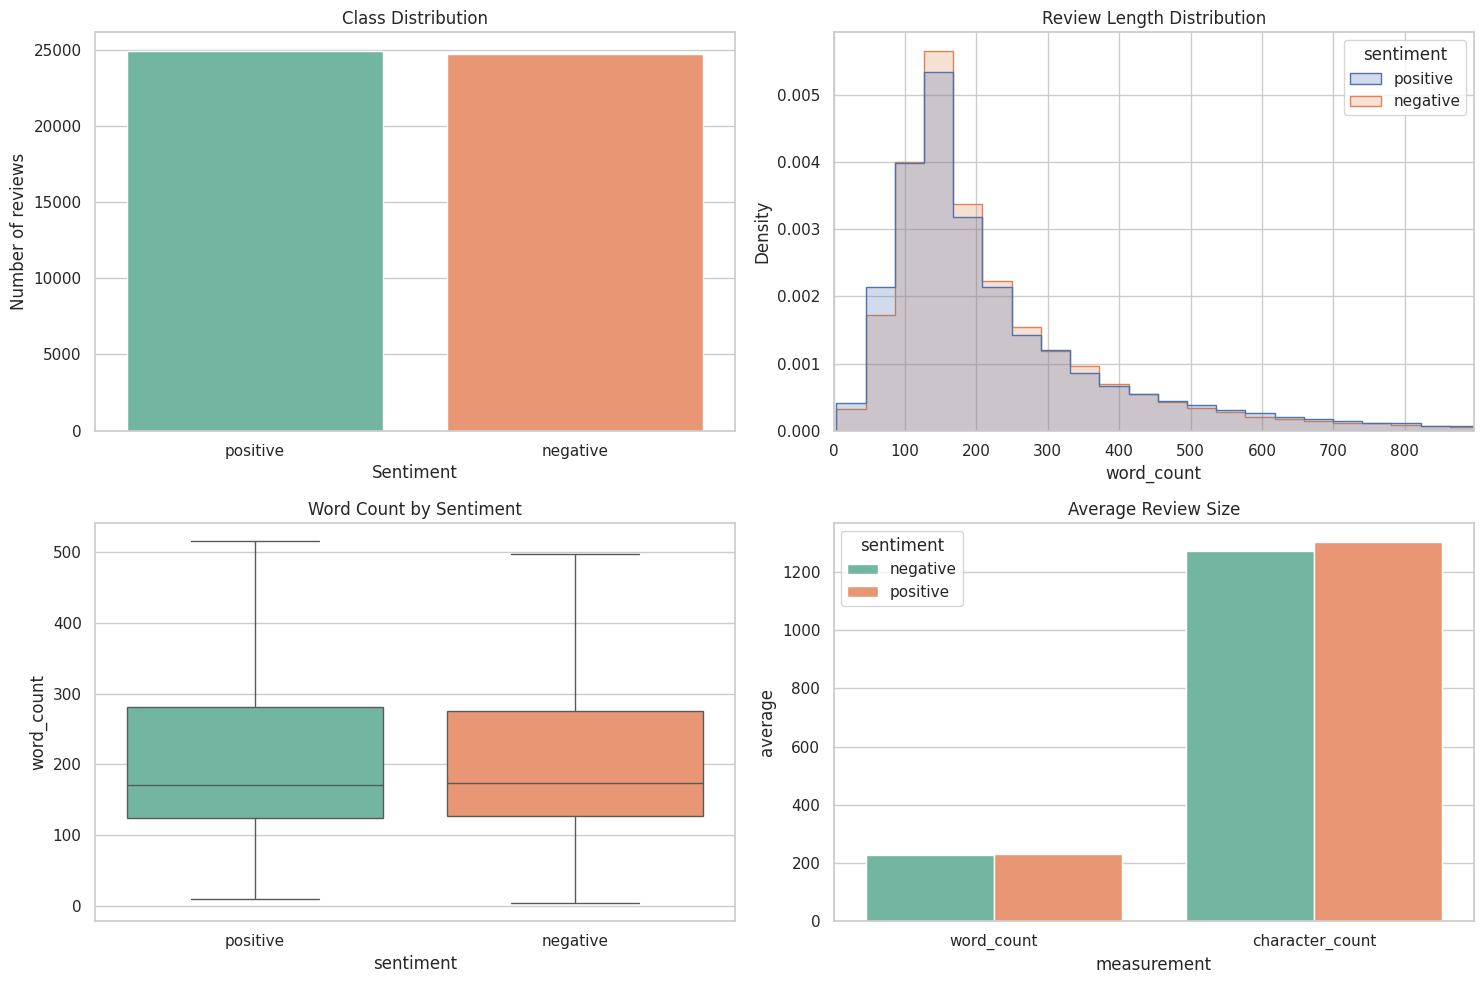

word_count                                                      \
               count    mean     std   min    25%    50%     75%     max   
sentiment                                                                  
negative     24698.0  227.24  163.34   4.0  127.0  173.0  275.75  1491.0   
positive     24884.0  230.86  175.94  10.0  124.0  171.0  281.00  2459.0   

          character_count                                                \
                    count     mean      std   min    25%    50%     75%   
sentiment                                                                 
negative          24698.0  1271.41   928.93  32.0  697.0  957.0  1538.0   
positive          24884.0  1304.25  1015.40  65.0  683.0  953.0  1587.0   

                    
               max  
sentiment           
negative    8698.0  
positive   13593.0

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x="sentiment", hue="sentiment", palette="Set2", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_xlabel("Sentiment")
axes[0, 0].set_ylabel("Number of reviews")

sns.histplot(data=df, x="word_count", hue="sentiment", bins=60, element="step", stat="density", common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Review Length Distribution")
axes[0, 1].set_xlim(0, df["word_count"].quantile(0.99))

sns.boxplot(data=df, x="sentiment", y="word_count", hue="sentiment", palette="Set2", legend=False, showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Word Count by Sentiment")

summary = df.groupby("sentiment")[["word_count", "character_count"]].mean().reset_index()
summary_melted = summary.melt(id_vars="sentiment", var_name="measurement", value_name="average")
sns.barplot(data=summary_melted, x="measurement", y="average", hue="sentiment", palette="Set2", ax=axes[1, 1])
axes[1, 1].set_title("Average Review Size")

plt.tight_layout()
plt.show()

display(df.groupby("sentiment")[["word_count", "character_count"]].describe().round(2))


## Step 7 — Word clouds and frequent words


**Code explanation:** Builds separate positive and negative word clouds from sampled reviews. Sampling keeps the visualization fast while still showing the dominant vocabulary of each class.


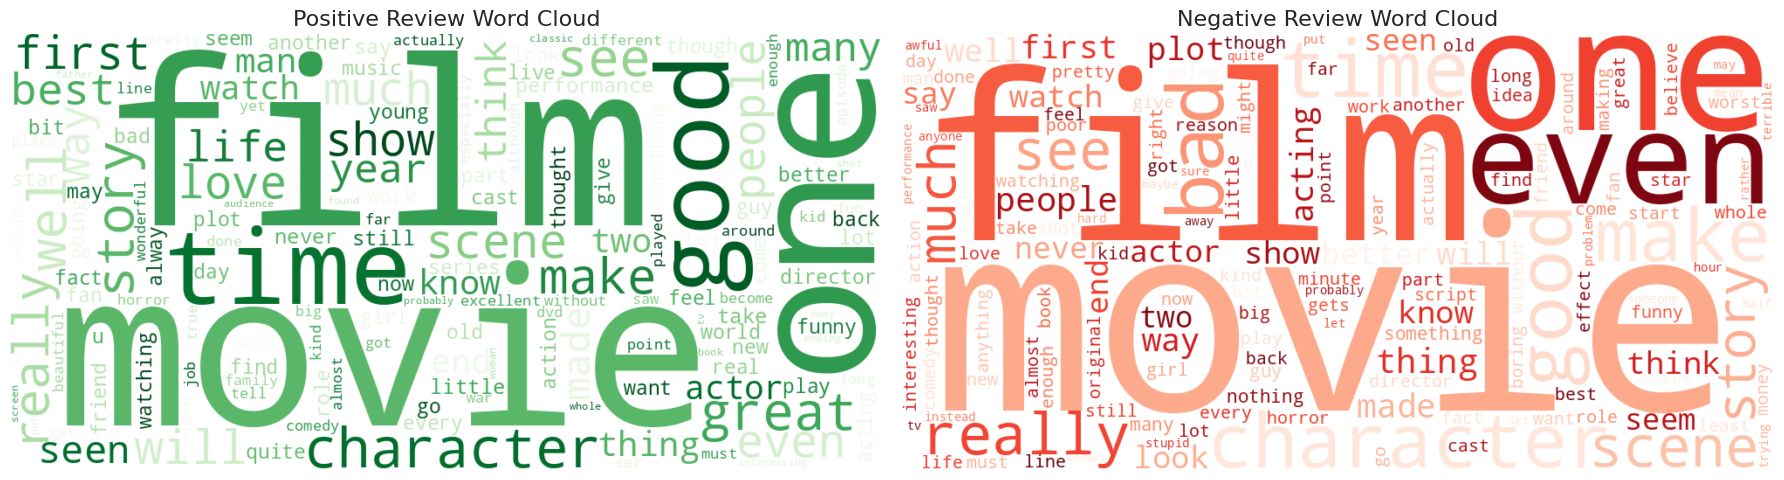

In [7]:
def make_wordcloud(text_series, title, colormap):
    # Sampling keeps this visualization fast and memory-friendly.
    sample = text_series.sample(min(5000, len(text_series)), random_state=SEED)
    combined_text = " ".join(sample).lower()
    cloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        colormap=colormap,
        max_words=150,
        collocations=False,
    ).generate(combined_text)
    plt.imshow(cloud, interpolation="bilinear")
    plt.title(title, fontsize=16)
    plt.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.sca(axes[0])
make_wordcloud(df.loc[df["label"] == 1, "clean_review"], "Positive Review Word Cloud", "Greens")
plt.sca(axes[1])
make_wordcloud(df.loc[df["label"] == 0, "clean_review"], "Negative Review Word Cloud", "Reds")
plt.tight_layout()
plt.show()


**Code explanation:** Tokenizes sampled text with a simple regular expression, removes common display-only stopwords, counts word frequencies and plots the twenty most frequent informative words for each sentiment.


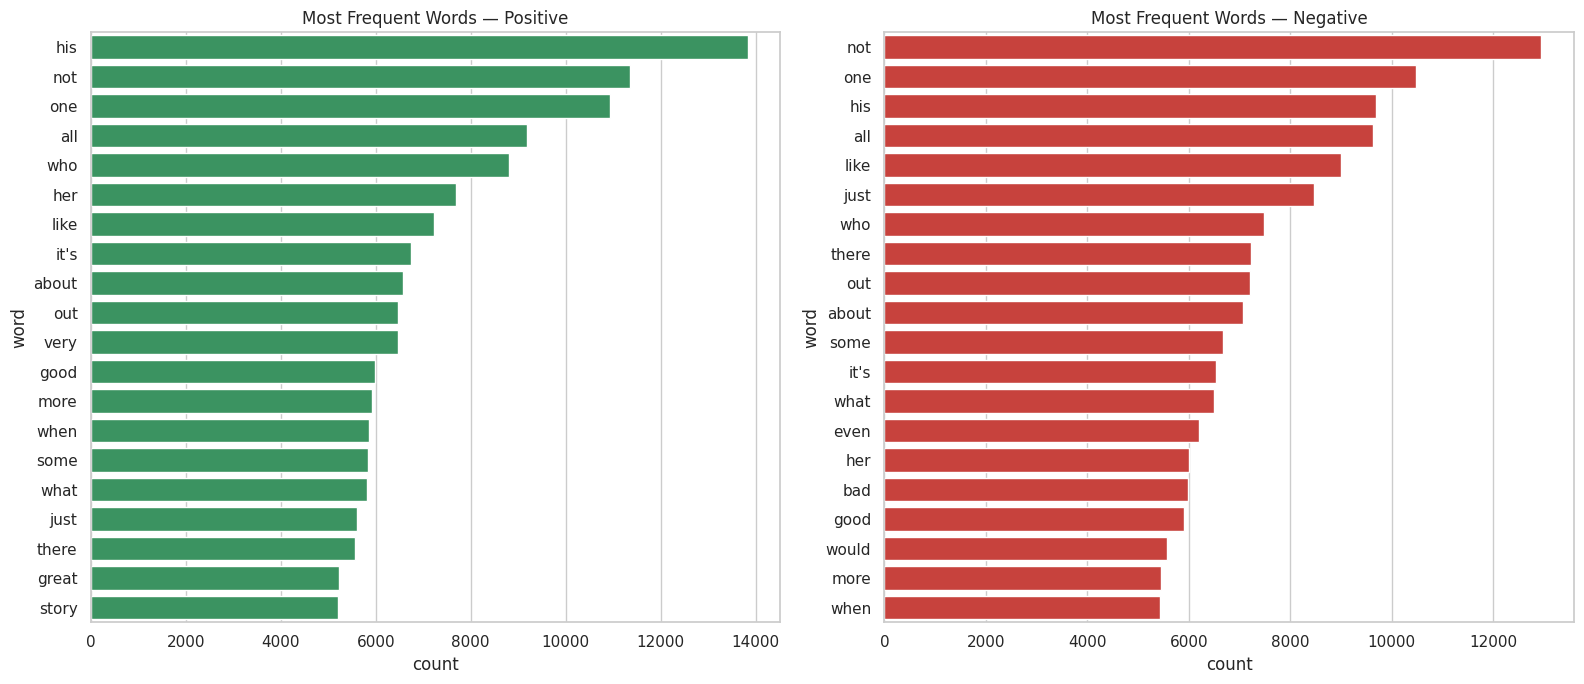

In [8]:
from collections import Counter

STOPWORDS_FOR_CHART = {
    "the", "a", "an", "and", "or", "but", "of", "to", "in", "is", "it", "this",
    "that", "was", "with", "for", "as", "on", "movie", "film", "be", "are", "have",
    "has", "had", "i", "you", "he", "she", "they", "we", "at", "by", "from",
}

def top_words(text_series, n=20):
    sample = text_series.sample(min(10000, len(text_series)), random_state=SEED)
    words = re.findall(r"[a-zA-Z']+", " ".join(sample).lower())
    words = [w for w in words if len(w) > 2 and w not in STOPWORDS_FOR_CHART]
    return pd.DataFrame(Counter(words).most_common(n), columns=["word", "count"])

positive_words = top_words(df.loc[df["label"] == 1, "clean_review"])
negative_words = top_words(df.loc[df["label"] == 0, "clean_review"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=positive_words, y="word", x="count", color="#2ca25f", ax=axes[0])
axes[0].set_title("Most Frequent Words — Positive")
sns.barplot(data=negative_words, y="word", x="count", color="#de2d26", ax=axes[1])
axes[1].set_title("Most Frequent Words — Negative")
plt.tight_layout()
plt.show()


## Step 8 — Create stratified train, validation and test sets

We use one fixed split for every model:

- 80% training
- 10% validation
- 10% final test

`stratify` keeps approximately the same positive/negative ratio in every split. The test set remains unseen during training.


**Code explanation:** Creates fixed, stratified train/validation/test partitions in an 80/10/10 ratio. Stratification preserves the positive/negative proportion and the untouched test set provides the final evaluation.


In [9]:
train_df, temp_df = train_test_split(
    df[["clean_review", "label", "sentiment"]],
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"],
)
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "positive_ratio": [train_df.label.mean(), validation_df.label.mean(), test_df.label.mean()],
})
display(split_summary)


,split,rows,positive_ratio
0,train,39665,0.501878
1,validation,4958,0.501815
2,test,4959,0.501916


## Step 9 — Choose quick or full experiment settings


**Code explanation:** Defines quick/full experiment sizes, epoch count, maximum token length, learning rate and model-saving behavior. The helper selects stratified subsets so quick mode stays balanced.


In [10]:
# ----------------------- MAIN SETTINGS -----------------------
RUN_MODE = "quick"                 # "quick" or "full"
TRAINING_STRATEGY = "memory_safe"  # "memory_safe" or "full"
SAVE_BEST_MODEL = True             # Keep only the current best model
SAVE_ALL_MODELS = False            # True can consume many GB for 14 models

OUTPUT_ROOT = Path("imdb_bert_results")
BEST_MODEL_DIR = OUTPUT_ROOT / "best_model_for_deployment"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if RUN_MODE == "quick":
    TRAIN_LIMIT = 4000
    VALIDATION_LIMIT = 1000
    TEST_LIMIT = 1000
    NUM_EPOCHS = 3
    MAX_LENGTH = 128
else:
    TRAIN_LIMIT = None
    VALIDATION_LIMIT = None
    TEST_LIMIT = None
    NUM_EPOCHS = 5
    MAX_LENGTH = 256

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

def stratified_limit(frame, limit):
    if limit is None or limit >= len(frame):
        return frame.reset_index(drop=True)
    selected, _ = train_test_split(
        frame,
        train_size=limit,
        random_state=SEED,
        stratify=frame["label"],
    )
    return selected.reset_index(drop=True)

active_train_df = stratified_limit(train_df, TRAIN_LIMIT)
active_validation_df = stratified_limit(validation_df, VALIDATION_LIMIT)
active_test_df = stratified_limit(test_df, TEST_LIMIT)

print("Run mode:", RUN_MODE)
print("Training strategy:", TRAINING_STRATEGY)
print("Rows:", len(active_train_df), len(active_validation_df), len(active_test_df))
print("Epochs:", NUM_EPOCHS, "| Maximum tokens:", MAX_LENGTH)
print("Best-model folder:", BEST_MODEL_DIR)


Run mode: quick
Training strategy: memory_safe
Rows: 4000 1000 1000
Epochs: 3 | Maximum tokens: 128
Best-model folder: imdb_bert_results/best_model_for_deployment


## Step 10 — Define all 14 checkpoints

Each dictionary entry stores a display name, the Hugging Face checkpoint, the per-device batch size and gradient accumulation value. Their product is the effective batch size. `use_fast=False` selects the Python/SentencePiece tokenizer for checkpoints that are more reliable with it.

The `heavy=True` flag tells the training loop to use head-only training when `TRAINING_STRATEGY="memory_safe"`. The `disable_gradient_checkpointing=True` flag prevents the earlier mDeBERTa backward-graph error.

If a model runs out of memory, reduce its `batch_size` and increase `grad_accum` so the effective batch remains similar.


**Code explanation:** Registers all 14 Hugging Face checkpoints and their memory settings. It also displays the effective batch size, training strategy and gradient-checkpointing choice before training begins.


In [11]:
MODEL_CONFIGS = {
    "BERT-base": {
        "checkpoint": "google-bert/bert-base-uncased", "batch_size": 16, "grad_accum": 1,
    },
    "mBERT": {
        "checkpoint": "google-bert/bert-base-multilingual-cased", "batch_size": 8, "grad_accum": 2,
    },
    "XLM-RoBERTa-base": {
        "checkpoint": "FacebookAI/xlm-roberta-base", "batch_size": 8, "grad_accum": 2,
    },
    "mDeBERTa-v3-base": {
        "checkpoint": "microsoft/mdeberta-v3-base",
        "batch_size": 2,
        "grad_accum": 8,
        "use_fast": False,
        "disable_gradient_checkpointing": True,
    },
    "RemBERT": {
        "checkpoint": "google/rembert", "batch_size": 2, "grad_accum": 8, "heavy": True,
    },
    "ALBERT-base": {
        "checkpoint": "albert/albert-base-v2", "batch_size": 16, "grad_accum": 1,
    },
    "DistilBERT": {
        "checkpoint": "distilbert/distilbert-base-uncased", "batch_size": 16, "grad_accum": 1,
    },
    "TinyBERT": {
        "checkpoint": "huawei-noah/TinyBERT_General_4L_312D", "batch_size": 32, "grad_accum": 1,
    },
    "DeBERTa-v2": {
        "checkpoint": "microsoft/deberta-v2-xlarge",
        "batch_size": 1,
        "grad_accum": 16,
        "heavy": True,
        "use_fast": False,
    },
    "ModernBERT-base": {
        "checkpoint": "answerdotai/ModernBERT-base", "batch_size": 8, "grad_accum": 2,
    },
    "RoBERTa-base": {
        "checkpoint": "FacebookAI/roberta-base", "batch_size": 8, "grad_accum": 2,
    },
    "IndicBERT-v2": {
        "checkpoint": "ai4bharat/IndicBERTv2-MLM-only", "batch_size": 4, "grad_accum": 4, "use_fast": False,
    },
    "MuRIL": {
        "checkpoint": "google/muril-base-cased", "batch_size": 8, "grad_accum": 2,
    },
    "ELECTRA-base": {
        "checkpoint": "google/electra-base-discriminator", "batch_size": 8, "grad_accum": 2,
    },
}

# All 14 models are selected by default.
# For a one-model test, use: MODELS_TO_RUN = ["ELECTRA-base"]
MODELS_TO_RUN = list(MODEL_CONFIGS.keys())

model_table = pd.DataFrame([
    {
        "model": name,
        "checkpoint": config["checkpoint"],
        "batch_size": config["batch_size"],
        "effective_batch": config["batch_size"] * config["grad_accum"],
        "default_strategy": "head_only" if config.get("heavy") and TRAINING_STRATEGY == "memory_safe" else "full_finetune",
        "gradient_checkpointing": "disabled" if config.get("disable_gradient_checkpointing") else "automatic",
    }
    for name, config in MODEL_CONFIGS.items()
])
display(model_table)


,model,checkpoint,batch_size,effective_batch,default_strategy,gradient_checkpointing
0,BERT-base,google-bert/bert-base-uncased,16,16,full_finetune,automatic
1,mBERT,google-bert/bert-base-multilingual-cased,8,16,full_finetune,automatic
2,XLM-RoBERTa-base,FacebookAI/xlm-roberta-base,8,16,full_finetune,automatic
3,mDeBERTa-v3-base,microsoft/mdeberta-v3-base,2,16,full_finetune,disabled
4,RemBERT,google/rembert,2,16,head_only,automatic
5,ALBERT-base,albert/albert-base-v2,16,16,full_finetune,automatic
6,DistilBERT,distilbert/distilbert-base-uncased,16,16,full_finetune,automatic
7,TinyBERT,huawei-noah/TinyBERT_General_4L_312D,32,32,full_finetune,automatic
8,DeBERTa-v2,microsoft/deberta-v2-xlarge,1,16,head_only,automatic
9,ModernBERT-base,answerdotai/ModernBERT-base,8,16,full_finetune,automatic


## Step 11 — Convert Pandas data into Hugging Face datasets

Each tokenizer divides text into its own subword tokens, so tokenization must be repeated inside the model loop. Padding is done dynamically to the longest review in each mini-batch, which saves memory compared with padding every review to `MAX_LENGTH`.


**Code explanation:** Converts the Pandas splits into Hugging Face `Dataset` objects. The text column is renamed to `text` and the numeric target to `labels`, which is the format expected by `Trainer`.


In [12]:
raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(
        active_train_df[["clean_review", "label"]].rename(columns={"clean_review": "text", "label": "labels"}),
        preserve_index=False,
    ),
    "validation": Dataset.from_pandas(
        active_validation_df[["clean_review", "label"]].rename(columns={"clean_review": "text", "label": "labels"}),
        preserve_index=False,
    ),
    "test": Dataset.from_pandas(
        active_test_df[["clean_review", "label"]].rename(columns={"clean_review": "text", "label": "labels"}),
        preserve_index=False,
    ),
})

raw_datasets


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 4000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
})

## Step 12 — Define evaluation and training helper functions


**Code explanation:** Defines label mappings, evaluation metrics, parameter counting, optional encoder freezing, confusion-matrix plotting and learning-curve plotting. These reusable functions keep the main training loop consistent for every model.


In [13]:
ID2LABEL = {0: "NEGATIVE", 1: "POSITIVE"}
LABEL2ID = {"NEGATIVE": 0, "POSITIVE": 1}

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)
    probabilities = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc_score(labels, probabilities),
    }


def count_parameters(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total, trainable


def freeze_encoder_keep_classifier(model):
    # Freeze the large encoder and keep only the task head trainable.
    for parameter in model.parameters():
        parameter.requires_grad = False

    head_keywords = ("classifier", "score", "classification_head")
    unfrozen_names = []
    for name, parameter in model.named_parameters():
        if any(keyword in name.lower() for keyword in head_keywords):
            parameter.requires_grad = True
            unfrozen_names.append(name)

    if not unfrozen_names:
        raise RuntimeError("Could not find the classification head to unfreeze.")
    return unfrozen_names


def plot_confusion_matrix_for_model(labels, predictions, model_name):
    matrix = confusion_matrix(labels, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
    )
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


def plot_learning_curve(log_history, model_name):
    training_points = [(row["step"], row["loss"]) for row in log_history if "loss" in row and "eval_loss" not in row]
    validation_points = [(row["step"], row["eval_loss"]) for row in log_history if "eval_loss" in row]
    if not training_points and not validation_points:
        return
    plt.figure(figsize=(7, 4))
    if training_points:
        x, y = zip(*training_points)
        plt.plot(x, y, marker="o", label="Training loss")
    if validation_points:
        x, y = zip(*validation_points)
        plt.plot(x, y, marker="s", label="Validation loss")
    plt.title(f"Learning Curve — {model_name}")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Step 13 — Train, evaluate and retain the best model

This is the main experiment cell. It:

1. Loads one tokenizer and model.
2. Tokenizes the same dataset split.
3. Trains the model.
4. Evaluates on the unseen test set.
5. Draws a confusion matrix and learning curve.
6. Stores results and error examples.
7. Saves the model only when it becomes the current winner.
8. Deletes it from GPU memory before loading the next model.

The winner is selected by `(F1, ROC-AUC, accuracy)`. This ensures that ELECTRA wins a displayed F1 tie with RoBERTa when ELECTRA has the higher ROC-AUC.


**Code explanation:** Runs the full experiment model by model. For each checkpoint it tokenizes text, dynamically pads batches, trains, evaluates, records metrics, plots diagnostics, saves a new winner, catches failures and releases GPU memory before continuing.



[1/14] BERT-base
Checkpoint: google-bert/bert-base-uncased
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 109.48M
Trainable parameters: 109.48M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.345900,0.347978,0.860000,0.886752,0.826693,0.855670,0.943229
2,0.249600,0.299370,0.876000,0.859316,0.900398,0.879377,0.951717
3,0.179600,0.399493,0.872000,0.880081,0.862550,0.871227,0.951663



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8648    0.8474    0.8560       498
    Positive     0.8516    0.8685    0.8600       502

    accuracy                         0.8580      1000
   macro avg     0.8582    0.8580    0.8580      1000
weighted avg     0.8581    0.8580    0.8580      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,BERT-base,google-bert/bert-base-uncased,full_finetune,0.858,0.8516,0.8685,0.86,0.9299,0.4829,2.1464,109.4838,109.4838,3,128,4000


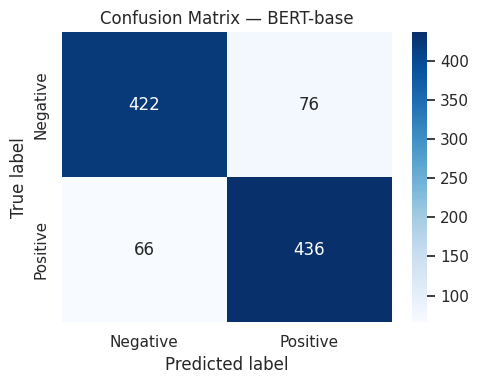

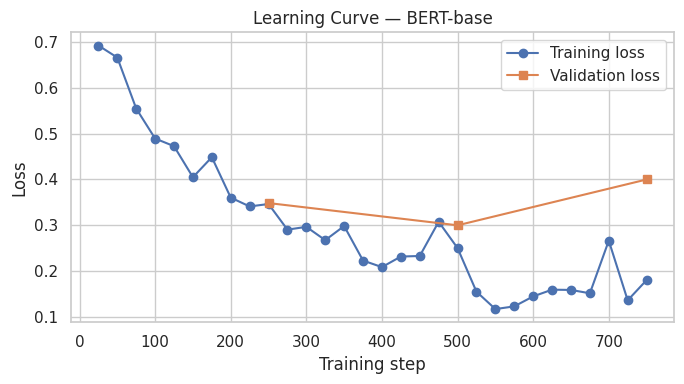

New best model saved for deployment: BERT-base

[2/14] mBERT
Checkpoint: google-bert/bert-base-multilingual-cased
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 177.85M
Trainable parameters: 177.85M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.429500,0.370060,0.828000,0.821012,0.840637,0.830709,0.918125
2,0.305400,0.365996,0.839000,0.829787,0.854582,0.842002,0.926369
3,0.214200,0.513593,0.841000,0.836935,0.848606,0.842730,0.930409



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8337    0.7952    0.8140       498
    Positive     0.8057    0.8426    0.8238       502

    accuracy                         0.8190      1000
   macro avg     0.8197    0.8189    0.8189      1000
weighted avg     0.8196    0.8190    0.8189      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,mBERT,google-bert/bert-base-multilingual-cased,full_finetune,0.819,0.8057,0.8426,0.8238,0.8981,0.6098,2.8679,177.855,177.855,3,128,4000


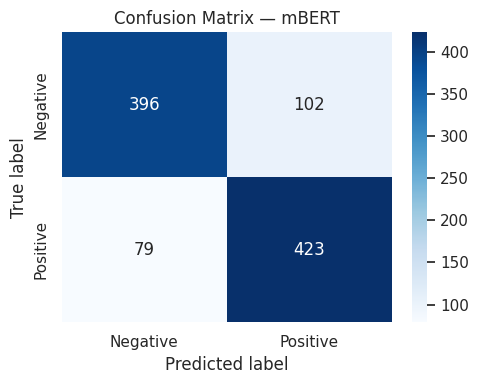

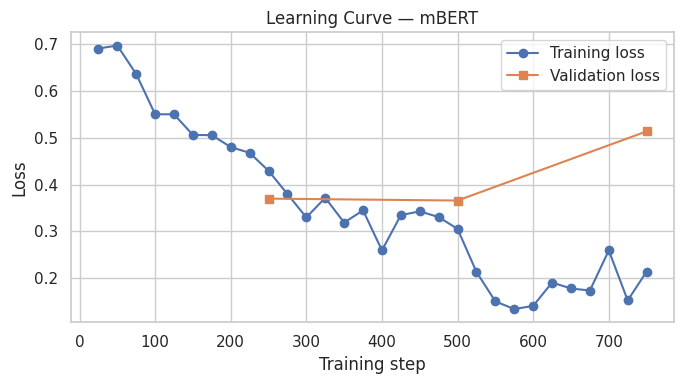


[3/14] XLM-RoBERTa-base
Checkpoint: FacebookAI/xlm-roberta-base
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 278.05M
Trainable parameters: 278.05M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.416600,0.318870,0.852000,0.831461,0.884462,0.857143,0.940791
2,0.351700,0.338090,0.866000,0.855212,0.882470,0.868627,0.942063
3,0.265100,0.483246,0.872000,0.858238,0.892430,0.875000,0.939923



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8737    0.8193    0.8456       498
    Positive     0.8311    0.8825    0.8560       502

    accuracy                         0.8510      1000
   macro avg     0.8524    0.8509    0.8508      1000
weighted avg     0.8523    0.8510    0.8508      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,XLM-RoBERTa-base,FacebookAI/xlm-roberta-base,full_finetune,0.851,0.8311,0.8825,0.856,0.9213,0.5407,3.8921,278.0452,278.0452,3,128,4000


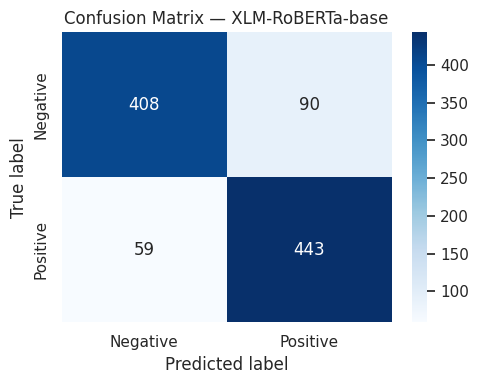

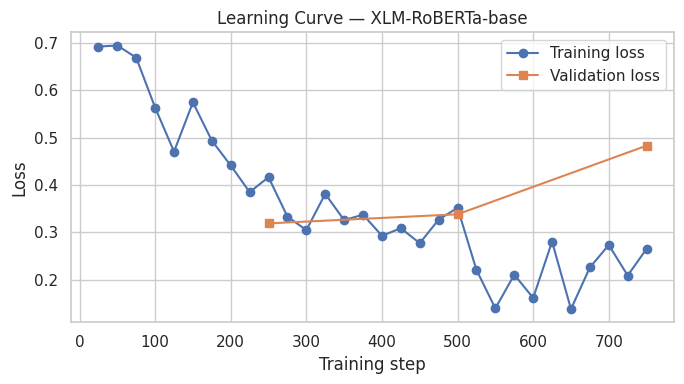


[4/14] mDeBERTa-v3-base
Checkpoint: microsoft/mdeberta-v3-base
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

Tokenizing for mDeBERTa-v3-base:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

Total parameters: 278.81M
Trainable parameters: 278.81M


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.381800,0.309251,0.861000,0.821239,0.924303,0.869728,0.950267
2,0.258300,0.304823,0.874000,0.854717,0.902390,0.877907,0.951709
3,0.160500,0.400336,0.878000,0.861217,0.902390,0.881323,0.952529



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8554    0.8434    0.8493       498
    Positive     0.8468    0.8586    0.8526       502

    accuracy                         0.8510      1000
   macro avg     0.8511    0.8510    0.8510      1000
weighted avg     0.8511    0.8510    0.8510      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,mDeBERTa-v3-base,microsoft/mdeberta-v3-base,full_finetune,0.851,0.8468,0.8586,0.8526,0.9257,0.5009,14.5362,278.8109,278.8109,3,128,4000


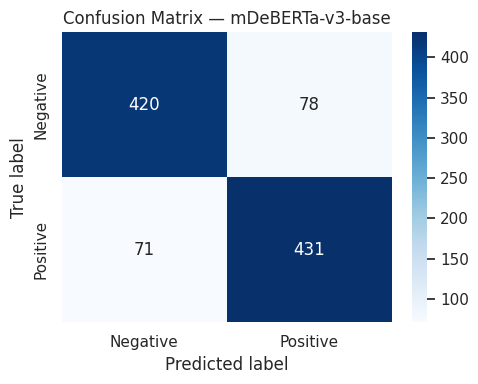

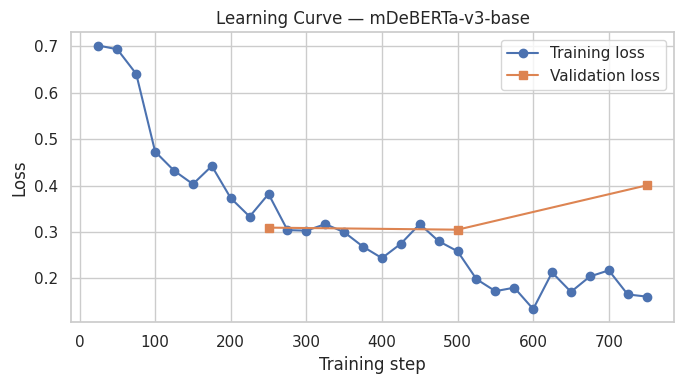


[5/14] RemBERT
Checkpoint: google/rembert
Strategy: head_only


tokenizer_config.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

sentencepiece.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

...

Some weights of RemBertForSequenceClassification were not initialized from the model checkpoint at google/rembert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Unfrozen classification-head tensors: 2
Total parameters: 575.92M
Trainable parameters: 0.00M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.690200,0.687961,0.624000,0.642534,0.565737,0.601695,0.677443
2,0.687500,0.686340,0.644000,0.644269,0.649402,0.646825,0.697903
3,0.688700,0.685803,0.653000,0.644320,0.689243,0.666025,0.702915



Test classification report:
              precision    recall  f1-score   support

    Negative     0.6159    0.5763    0.5954       498
    Positive     0.6049    0.6434    0.6236       502

    accuracy                         0.6100      1000
   macro avg     0.6104    0.6099    0.6095      1000
weighted avg     0.6104    0.6100    0.6096      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,RemBERT,google/rembert,head_only,0.61,0.6049,0.6434,0.6236,0.6652,0.6876,7.8995,575.9227,0.0023,3,128,4000


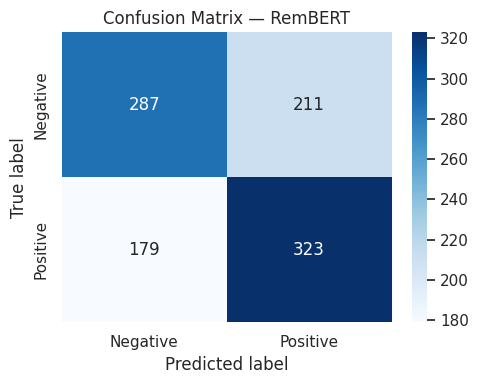

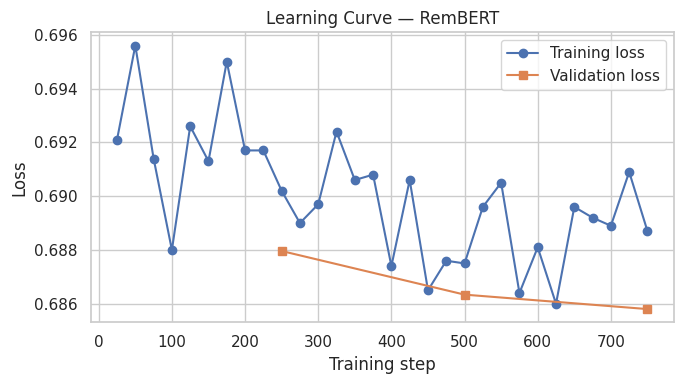


[6/14] ALBERT-base
Checkpoint: albert/albert-base-v2
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert/albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 11.69M
Trainable parameters: 11.69M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.463700,0.340631,0.858000,0.887931,0.820717,0.853002,0.940979
2,0.275500,0.331387,0.873000,0.889813,0.852590,0.870804,0.950537
3,0.164800,0.422457,0.876000,0.897059,0.850598,0.873211,0.949671



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8327    0.8896    0.8602       498
    Positive     0.8825    0.8227    0.8515       502

    accuracy                         0.8560      1000
   macro avg     0.8576    0.8561    0.8559      1000
weighted avg     0.8577    0.8560    0.8559      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,ALBERT-base,albert/albert-base-v2,full_finetune,0.856,0.8825,0.8227,0.8515,0.9328,0.4673,2.2315,11.6851,11.6851,3,128,4000


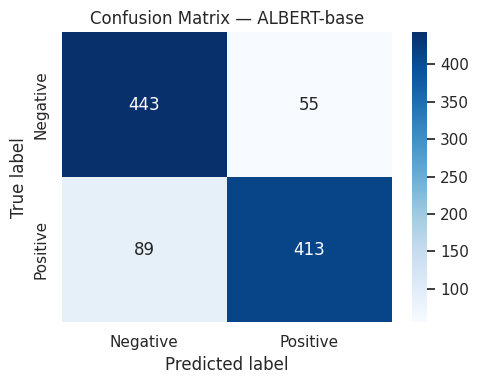

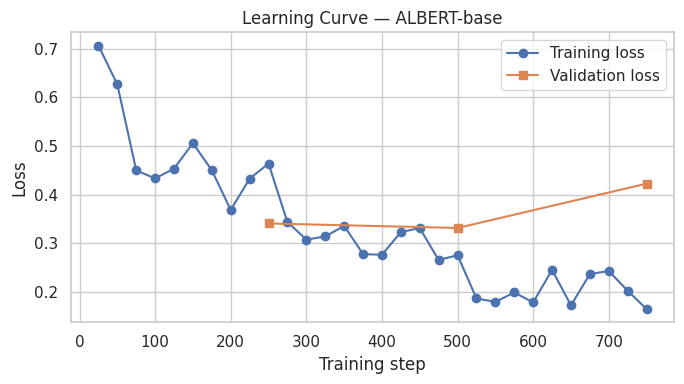


[7/14] DistilBERT
Checkpoint: distilbert/distilbert-base-uncased
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66.96M
Trainable parameters: 66.96M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.362700,0.316749,0.865000,0.878351,0.848606,0.863222,0.945557
2,0.254400,0.325693,0.860000,0.838951,0.892430,0.864865,0.946801
3,0.168900,0.373094,0.870000,0.875000,0.864542,0.869739,0.949049



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8435    0.8333    0.8384       498
    Positive     0.8366    0.8466    0.8416       502

    accuracy                         0.8400      1000
   macro avg     0.8401    0.8400    0.8400      1000
weighted avg     0.8400    0.8400    0.8400      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,DistilBERT,distilbert/distilbert-base-uncased,full_finetune,0.84,0.8366,0.8466,0.8416,0.9221,0.4523,1.2598,66.955,66.955,3,128,4000


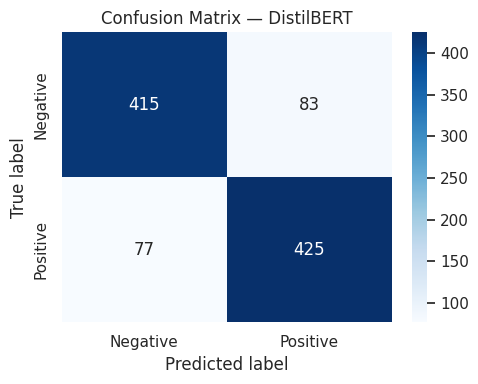

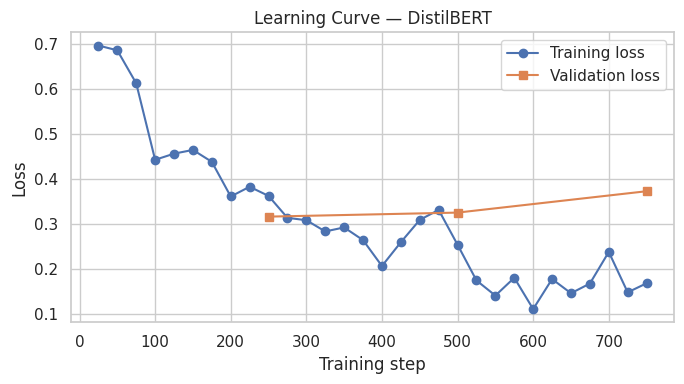


[8/14] TinyBERT
Checkpoint: huawei-noah/TinyBERT_General_4L_312D
Strategy: full_finetune


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizing for TinyBERT:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing for TinyBERT:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

Total parameters: 14.35M
Trainable parameters: 14.35M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.467500,0.453016,0.819000,0.839323,0.790837,0.814359,0.909783
2,0.415500,0.395668,0.839000,0.801770,0.902390,0.849110,0.923249
3,0.381100,0.384492,0.837000,0.839679,0.834661,0.837163,0.923207


model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]


Test classification report:
              precision    recall  f1-score   support

    Negative     0.7928    0.7912    0.7920       498
    Positive     0.7932    0.7948    0.7940       502

    accuracy                         0.7930      1000
   macro avg     0.7930    0.7930    0.7930      1000
weighted avg     0.7930    0.7930    0.7930      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,TinyBERT,huawei-noah/TinyBERT_General_4L_312D,full_finetune,0.793,0.7932,0.7948,0.794,0.8794,0.4627,0.5201,14.3509,14.3509,3,128,4000


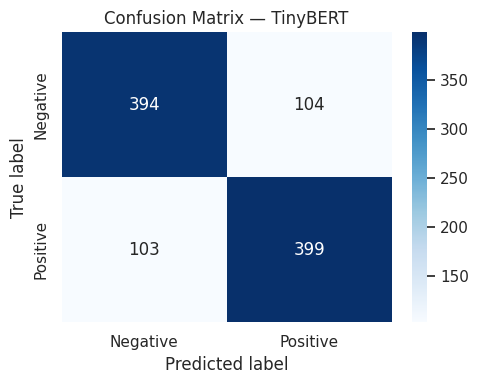

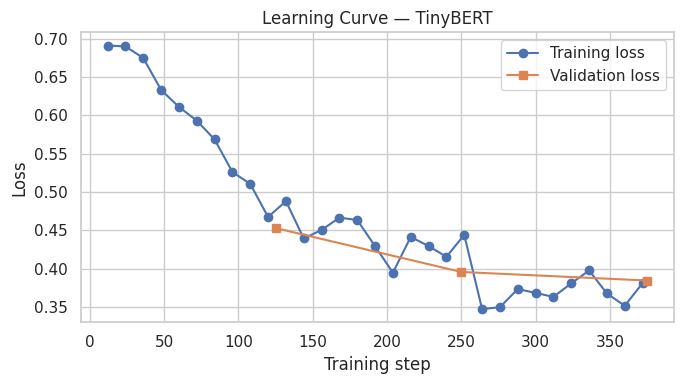


[9/14] DeBERTa-v2
Checkpoint: microsoft/deberta-v2-xlarge
Strategy: head_only


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/633 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

Tokenizing for DeBERTa-v2:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

Unfrozen classification-head tensors: 2
Total parameters: 886.96M
Trainable parameters: 0.00M


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.693900,0.692823,0.502000,0.502000,1.000000,0.668442,0.536723
2,0.700300,0.692744,0.509000,0.505908,0.938247,0.657362,0.538765
3,0.697200,0.692751,0.501000,0.501505,0.996016,0.667111,0.540617



Test classification report:
              precision    recall  f1-score   support

    Negative     0.1667    0.0020    0.0040       498
    Positive     0.5000    0.9900    0.6644       502

    accuracy                         0.4980      1000
   macro avg     0.3333    0.4960    0.3342      1000
weighted avg     0.3340    0.4980    0.3355      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,DeBERTa-v2,microsoft/deberta-v2-xlarge,head_only,0.498,0.5,0.99,0.6644,0.5301,0.6933,20.308,886.9571,0.0031,3,128,4000


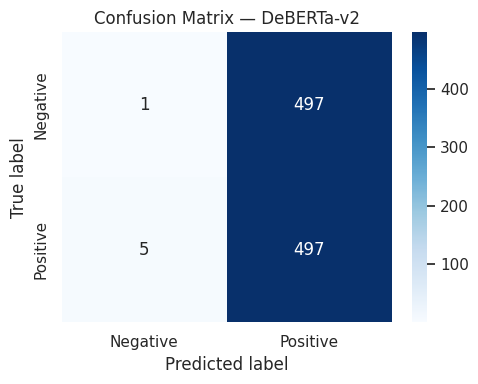

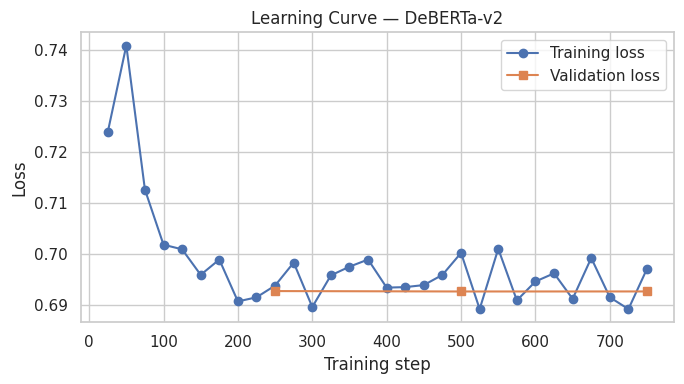


[10/14] ModernBERT-base
Checkpoint: answerdotai/ModernBERT-base
Strategy: full_finetune


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Tokenizing for ModernBERT-base:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

Total parameters: 149.61M
Trainable parameters: 149.61M


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.
W0813 16:58:22.312000 834 torch/_inductor/utils.py:1731] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.572900,0.257726,0.901000,0.915464,0.884462,0.899696,0.963921
2,0.387400,0.278798,0.902000,0.899209,0.906375,0.902778,0.965981
3,0.171200,0.522859,0.901000,0.908722,0.892430,0.900503,0.965533



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8715    0.8855    0.8785       498
    Positive     0.8846    0.8705    0.8775       502

    accuracy                         0.8780      1000
   macro avg     0.8781    0.8780    0.8780      1000
weighted avg     0.8781    0.8780    0.8780      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,ModernBERT-base,answerdotai/ModernBERT-base,full_finetune,0.878,0.8846,0.8705,0.8775,0.9499,0.6077,4.3647,149.6064,149.6064,3,128,4000


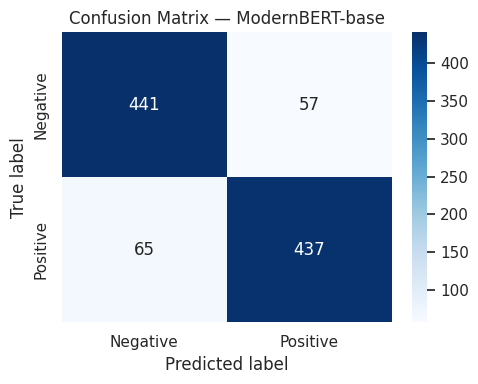

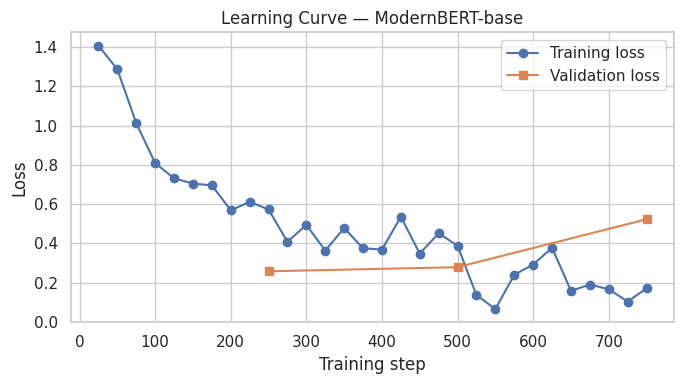

New best model saved for deployment: ModernBERT-base

[11/14] RoBERTa-base
Checkpoint: FacebookAI/roberta-base
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 124.65M
Trainable parameters: 124.65M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.357400,0.273949,0.887000,0.882122,0.894422,0.888229,0.959903
2,0.264100,0.309379,0.891000,0.877159,0.910359,0.893451,0.959543
3,0.112600,0.414140,0.894000,0.892857,0.896414,0.894632,0.962365



Test classification report:
              precision    recall  f1-score   support

    Negative     0.9121    0.8956    0.9037       498
    Positive     0.8982    0.9143    0.9062       502

    accuracy                         0.9050      1000
   macro avg     0.9052    0.9050    0.9050      1000
weighted avg     0.9051    0.9050    0.9050      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,RoBERTa-base,FacebookAI/roberta-base,full_finetune,0.905,0.8982,0.9143,0.9062,0.9567,0.3876,2.7565,124.6472,124.6472,3,128,4000


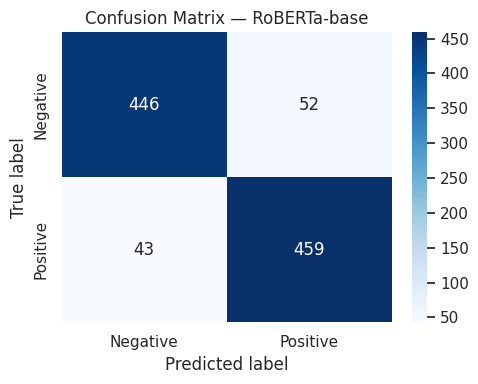

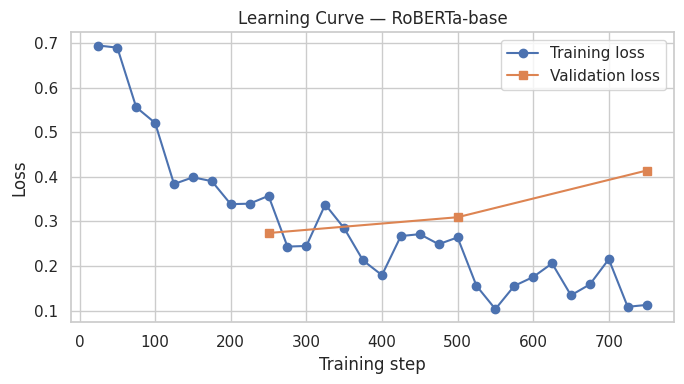

New best model saved for deployment: RoBERTa-base

[12/14] IndicBERT-v2
Checkpoint: ai4bharat/IndicBERTv2-MLM-only
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizing for IndicBERT-v2:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 3}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.371000,0.315555,0.873000,0.875752,0.870518,0.873127,0.941417
2,0.301400,0.317041,0.876000,0.881048,0.870518,0.875752,0.945543
3,0.212100,0.370746,0.878000,0.869650,0.890438,0.879921,0.946519



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8589    0.8313    0.8449       498
    Positive     0.8378    0.8645    0.8510       502

    accuracy                         0.8480      1000
   macro avg     0.8484    0.8479    0.8479      1000
weighted avg     0.8483    0.8480    0.8480      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,IndicBERT-v2,ai4bharat/IndicBERTv2-MLM-only,full_finetune,0.848,0.8378,0.8645,0.851,0.927,0.4397,6.7855,278.0429,278.0429,3,128,4000


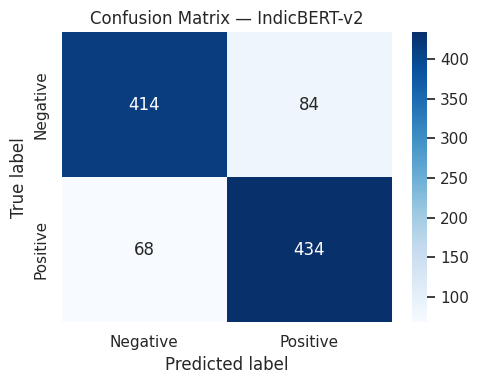

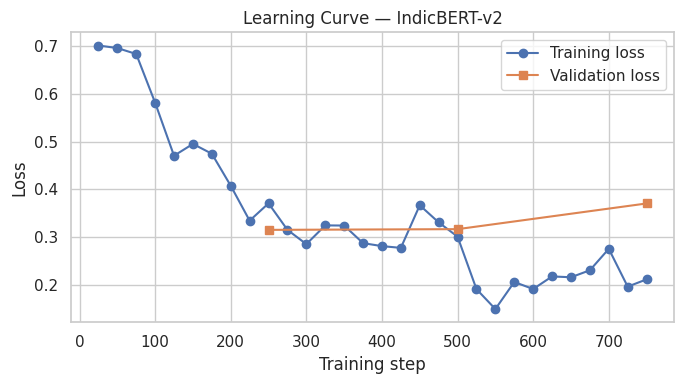


[13/14] MuRIL
Checkpoint: google/muril-base-cased
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

...

Total parameters: 237.56M
Trainable parameters: 237.56M


model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.502900,0.494386,0.822000,0.882075,0.745020,0.807775,0.900892
2,0.406200,0.405929,0.850000,0.829588,0.882470,0.855212,0.929013
3,0.347500,0.392783,0.851000,0.840077,0.868526,0.854065,0.933813



Test classification report:
              precision    recall  f1-score   support

    Negative     0.8428    0.8072    0.8246       498
    Positive     0.8164    0.8506    0.8332       502

    accuracy                         0.8290      1000
   macro avg     0.8296    0.8289    0.8289      1000
weighted avg     0.8296    0.8290    0.8289      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,MuRIL,google/muril-base-cased,full_finetune,0.829,0.8164,0.8506,0.8332,0.908,0.4392,4.1904,237.5578,237.5578,3,128,4000


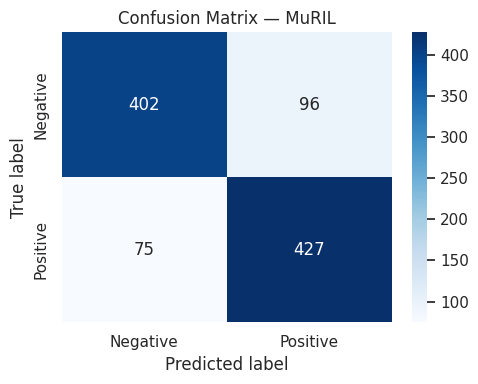

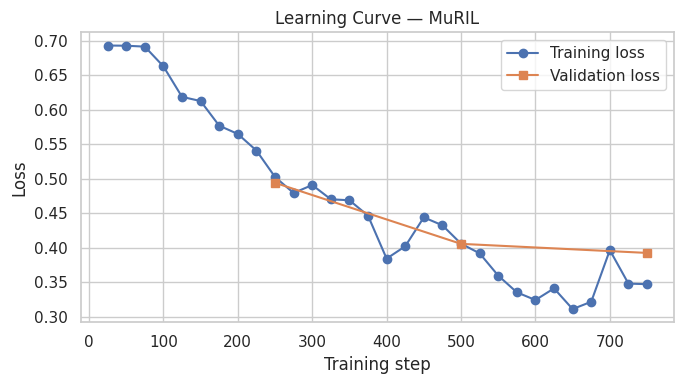


[14/14] ELECTRA-base
Checkpoint: google/electra-base-discriminator
Strategy: full_finetune


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 109.48M
Trainable parameters: 109.48M


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.311500,0.267995,0.898000,0.908163,0.886454,0.897177,0.963471
2,0.253600,0.282544,0.905000,0.907816,0.902390,0.905095,0.964523
3,0.135300,0.351075,0.903000,0.902584,0.904382,0.903483,0.965073



Test classification report:
              precision    recall  f1-score   support

    Negative     0.9121    0.8956    0.9037       498
    Positive     0.8982    0.9143    0.9062       502

    accuracy                         0.9050      1000
   macro avg     0.9052    0.9050    0.9050      1000
weighted avg     0.9051    0.9050    0.9050      1000



,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,ELECTRA-base,google/electra-base-discriminator,full_finetune,0.905,0.8982,0.9143,0.9062,0.959,0.3464,3.1912,109.4838,109.4838,3,128,4000


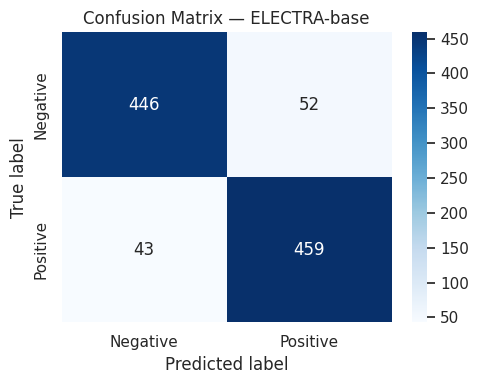

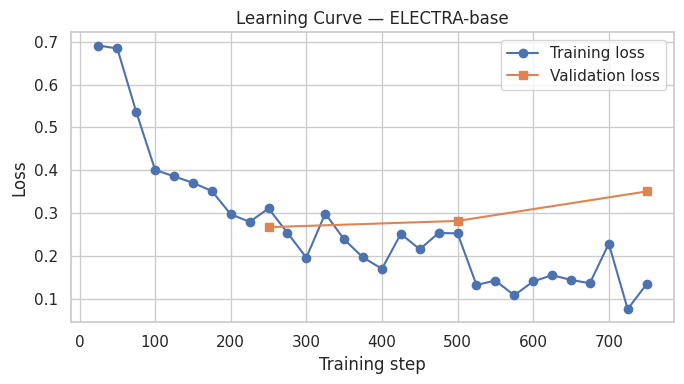

New best model saved for deployment: ELECTRA-base

Experiment loop finished.
Saved deployment winner: ELECTRA-base


In [14]:
results = []
failed_models = []
all_predictions = {}
all_histories = {}
best_score_so_far = (-np.inf, -np.inf, -np.inf)
best_model_name_saved = None

for model_number, model_name in enumerate(MODELS_TO_RUN, start=1):
    config = MODEL_CONFIGS[model_name]
    checkpoint = config["checkpoint"]
    batch_size = config["batch_size"]
    grad_accum = config["grad_accum"]
    use_fast = config.get("use_fast", True)
    heavy_model = config.get("heavy", False)
    strategy = "head_only" if heavy_model and TRAINING_STRATEGY == "memory_safe" else "full_finetune"

    print("\n" + "=" * 90)
    print(f"[{model_number}/{len(MODELS_TO_RUN)}] {model_name}")
    print("Checkpoint:", checkpoint)
    print("Strategy:", strategy)
    print("=" * 90)

    tokenizer = model = trainer = tokenized_datasets = None
    start_time = time.time()

    try:
        tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=use_fast)

        def tokenize_batch(batch):
            return tokenizer(
                batch["text"],
                truncation=True,
                max_length=MAX_LENGTH,
            )

        tokenized_datasets = raw_datasets.map(
            tokenize_batch,
            batched=True,
            remove_columns=["text"],
            desc=f"Tokenizing for {model_name}",
        )

        data_collator = DataCollatorWithPadding(
            tokenizer=tokenizer,
            pad_to_multiple_of=8 if torch.cuda.is_available() else None,
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            checkpoint,
            num_labels=2,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            ignore_mismatched_sizes=True,
        )

        if strategy == "head_only":
            unfrozen = freeze_encoder_keep_classifier(model)
            print(f"Unfrozen classification-head tensors: {len(unfrozen)}")
        elif (
            hasattr(model, "gradient_checkpointing_enable")
            and batch_size <= 4
            and not config.get("disable_gradient_checkpointing", False)
        ):
            model.gradient_checkpointing_enable()
            if hasattr(model.config, "use_cache"):
                model.config.use_cache = False

        total_parameters, trainable_parameters = count_parameters(model)
        print(f"Total parameters: {total_parameters / 1e6:.2f}M")
        print(f"Trainable parameters: {trainable_parameters / 1e6:.2f}M")

        output_dir = OUTPUT_ROOT / model_name.replace(" ", "_").replace("/", "-")
        logging_steps = max(10, len(tokenized_datasets["train"]) // max(batch_size * grad_accum * 10, 1))

        training_args = TrainingArguments(
            output_dir=str(output_dir),
            learning_rate=LEARNING_RATE,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=max(1, batch_size * 2),
            gradient_accumulation_steps=grad_accum,
            num_train_epochs=NUM_EPOCHS,
            weight_decay=WEIGHT_DECAY,
            warmup_ratio=0.10,
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="steps",
            logging_steps=logging_steps,
            fp16=torch.cuda.is_available(),
            report_to="none",
            seed=SEED,
            data_seed=SEED,
            dataloader_num_workers=2,
            optim="adamw_torch",
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_datasets["train"],
            eval_dataset=tokenized_datasets["validation"],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        trainer.train()
        prediction_output = trainer.predict(tokenized_datasets["test"])

        logits = prediction_output.predictions
        if isinstance(logits, tuple):
            logits = logits[0]
        y_true = prediction_output.label_ids
        y_pred = np.argmax(logits, axis=-1)
        y_probability = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        elapsed_minutes = (time.time() - start_time) / 60

        result = {
            "model": model_name,
            "checkpoint": checkpoint,
            "strategy": strategy,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc_score(y_true, y_probability),
            "test_loss": prediction_output.metrics.get("test_loss", np.nan),
            "runtime_minutes": elapsed_minutes,
            "total_parameters_m": total_parameters / 1e6,
            "trainable_parameters_m": trainable_parameters / 1e6,
            "epochs": NUM_EPOCHS,
            "max_length": MAX_LENGTH,
            "train_rows": len(tokenized_datasets["train"]),
        }
        results.append(result)
        all_predictions[model_name] = {
            "labels": y_true.tolist(),
            "predictions": y_pred.tolist(),
            "positive_probability": y_probability.tolist(),
        }
        all_histories[model_name] = trainer.state.log_history

        print("\nTest classification report:")
        print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"], digits=4))
        display(pd.DataFrame([result]).round(4))
        plot_confusion_matrix_for_model(y_true, y_pred, model_name)
        plot_learning_curve(trainer.state.log_history, model_name)

        current_score = (result["f1"], result["roc_auc"], result["accuracy"])
        if SAVE_BEST_MODEL and current_score > best_score_so_far:
            if BEST_MODEL_DIR.exists():
                shutil.rmtree(BEST_MODEL_DIR)
            BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

            trainer.save_model(str(BEST_MODEL_DIR))
            tokenizer.save_pretrained(str(BEST_MODEL_DIR))

            deployment_metadata = {
                "model_name": model_name,
                "source_checkpoint": checkpoint,
                "selection_rule": "highest F1, then ROC-AUC, then accuracy",
                "accuracy": float(result["accuracy"]),
                "precision": float(result["precision"]),
                "recall": float(result["recall"]),
                "f1": float(result["f1"]),
                "roc_auc": float(result["roc_auc"]),
                "max_length": MAX_LENGTH,
                "id2label": ID2LABEL,
                "cleaning": "HTML/URL removal, whitespace normalization; tokenizer handles subwords",
            }
            with open(BEST_MODEL_DIR / "deployment_metadata.json", "w", encoding="utf-8") as file:
                json.dump(deployment_metadata, file, indent=2)

            (BEST_MODEL_DIR / "requirements.txt").write_text(
                "torch>=2.1.0\ntransformers>=4.48.0,<5.0.0\nsafetensors>=0.4.0\n",
                encoding="utf-8",
            )
            (BEST_MODEL_DIR / "deployment_example.py").write_text(
                "from transformers import pipeline\n\n"
                "classifier = pipeline('sentiment-analysis', model='.', tokenizer='.')\n"
                "print(classifier('This movie was absolutely wonderful.'))\n",
                encoding="utf-8",
            )

            best_score_so_far = current_score
            best_model_name_saved = model_name
            print(f"New best model saved for deployment: {model_name}")

        if SAVE_ALL_MODELS:
            save_dir = output_dir / "final_model"
            trainer.save_model(str(save_dir))
            tokenizer.save_pretrained(str(save_dir))
            print("Additional model saved to:", save_dir)

        pd.DataFrame(results).to_csv(OUTPUT_ROOT / "model_results_partial.csv", index=False)
        with open(OUTPUT_ROOT / "predictions.json", "w", encoding="utf-8") as file:
            json.dump(all_predictions, file)

    except Exception as error:
        elapsed_minutes = (time.time() - start_time) / 60
        error_message = f"{type(error).__name__}: {error}"
        failed_models.append({
            "model": model_name,
            "checkpoint": checkpoint,
            "minutes_before_failure": elapsed_minutes,
            "error": error_message,
        })
        print(f"FAILED: {model_name}")
        print(error_message)
        if "out of memory" in str(error).lower():
            print("Tip: reduce this model's batch_size or use TRAINING_STRATEGY='memory_safe'.")

    finally:
        del tokenizer, model, trainer, tokenized_datasets
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\nExperiment loop finished.")
print("Saved deployment winner:", best_model_name_saved)


## Step 14 — Rank and save the model results


**Code explanation:** Converts the collected results into a ranked table. Models are ordered by F1-score, then ROC-AUC and accuracy; the table is saved as CSV and any failures are reported separately.


In [15]:
if not results:
    raise RuntimeError("No model completed successfully. Check the failed-model table below.")

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset="model", keep="last")
    .sort_values(
        by=["f1", "roc_auc", "accuracy"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)
results_df.insert(0, "rank_by_f1", np.arange(1, len(results_df) + 1))
results_df.to_csv(OUTPUT_ROOT / "final_model_comparison.csv", index=False)

display(results_df.round(4))

if failed_models:
    failed_df = pd.DataFrame(failed_models)
    failed_df.to_csv(OUTPUT_ROOT / "failed_models.csv", index=False)
    print("Models that did not finish:")
    display(failed_df)

best_row = results_df.iloc[0]
print("Best model:", best_row["model"])
print("F1:", round(best_row["f1"], 4))
print("ROC-AUC:", round(best_row["roc_auc"], 4))
print("Accuracy:", round(best_row["accuracy"], 4))
print("Deployment model saved in:", BEST_MODEL_DIR.resolve())
print("Result files saved in:", OUTPUT_ROOT.resolve())


,rank_by_f1,model,checkpoint,strategy,accuracy,precision,recall,f1,roc_auc,test_loss,runtime_minutes,total_parameters_m,trainable_parameters_m,epochs,max_length,train_rows
0,1,ELECTRA-base,google/electra-base-discriminator,full_finetune,0.905,0.8982,0.9143,0.9062,0.9590,0.3464,3.1912,109.4838,109.4838,3,128,4000
1,2,RoBERTa-base,FacebookAI/roberta-base,full_finetune,0.905,0.8982,0.9143,0.9062,0.9567,0.3876,2.7565,124.6472,124.6472,3,128,4000
2,3,ModernBERT-base,answerdotai/ModernBERT-base,full_finetune,0.878,0.8846,0.8705,0.8775,0.9499,0.6077,4.3647,149.6064,149.6064,3,128,4000
3,4,BERT-base,google-bert/bert-base-uncased,full_finetune,0.858,0.8516,0.8685,0.8600,0.9299,0.4829,2.1464,109.4838,109.4838,3,128,4000
4,5,XLM-RoBERTa-base,FacebookAI/xlm-roberta-base,full_finetune,0.851,0.8311,0.8825,0.8560,0.9213,0.5407,3.8921,278.0452,278.0452,3,128,4000
5,6,mDeBERTa-v3-base,microsoft/mdeberta-v3-base,full_finetune,0.851,0.8468,0.8586,0.8526,0.9257,0.5009,14.5362,278.8109,278.8109,3,128,4000
6,7,ALBERT-base,albert/albert-base-v2,full_finetune,0.856,0.8825,0.8227,0.8515,0.9328,0.4673,2.2315,11.6851,11.6851,3,128,4000
7,8,IndicBERT-v2,ai4bharat/IndicBERTv2-MLM-only,full_finetune,0.848,0.8378,0.8645,0.8510,0.9270,0.4397,6.7855,278.0429,278.0429,3,128,4000
8,9,DistilBERT,distilbert/distilbert-base-uncased,full_finetune,0.840,0.8366,0.8466,0.8416,0.9221,0.4523,1.2598,66.9550,66.9550,3,128,4000
9,10,MuRIL,google/muril-base-cased,full_finetune,0.829,0.8164,0.8506,0.8332,0.9080,0.4392,4.1904,237.5578,237.5578,3,128,4000


Best model: ELECTRA-base
F1: 0.9062
ROC-AUC: 0.959
Accuracy: 0.905
Deployment model saved in: /content/imdb_bert_results/best_model_for_deployment
Result files saved in: /content/imdb_bert_results


## Step 15 — Model comparison charts

The following visualizations compare predictive quality, loss, runtime, parameter count and performance-efficiency trade-offs. The best model is highlighted where appropriate.


**Code explanation:** Draws horizontal bar charts for accuracy, F1-score and ROC-AUC. Using the same model order makes it easy to see which architectures consistently perform well across metrics.


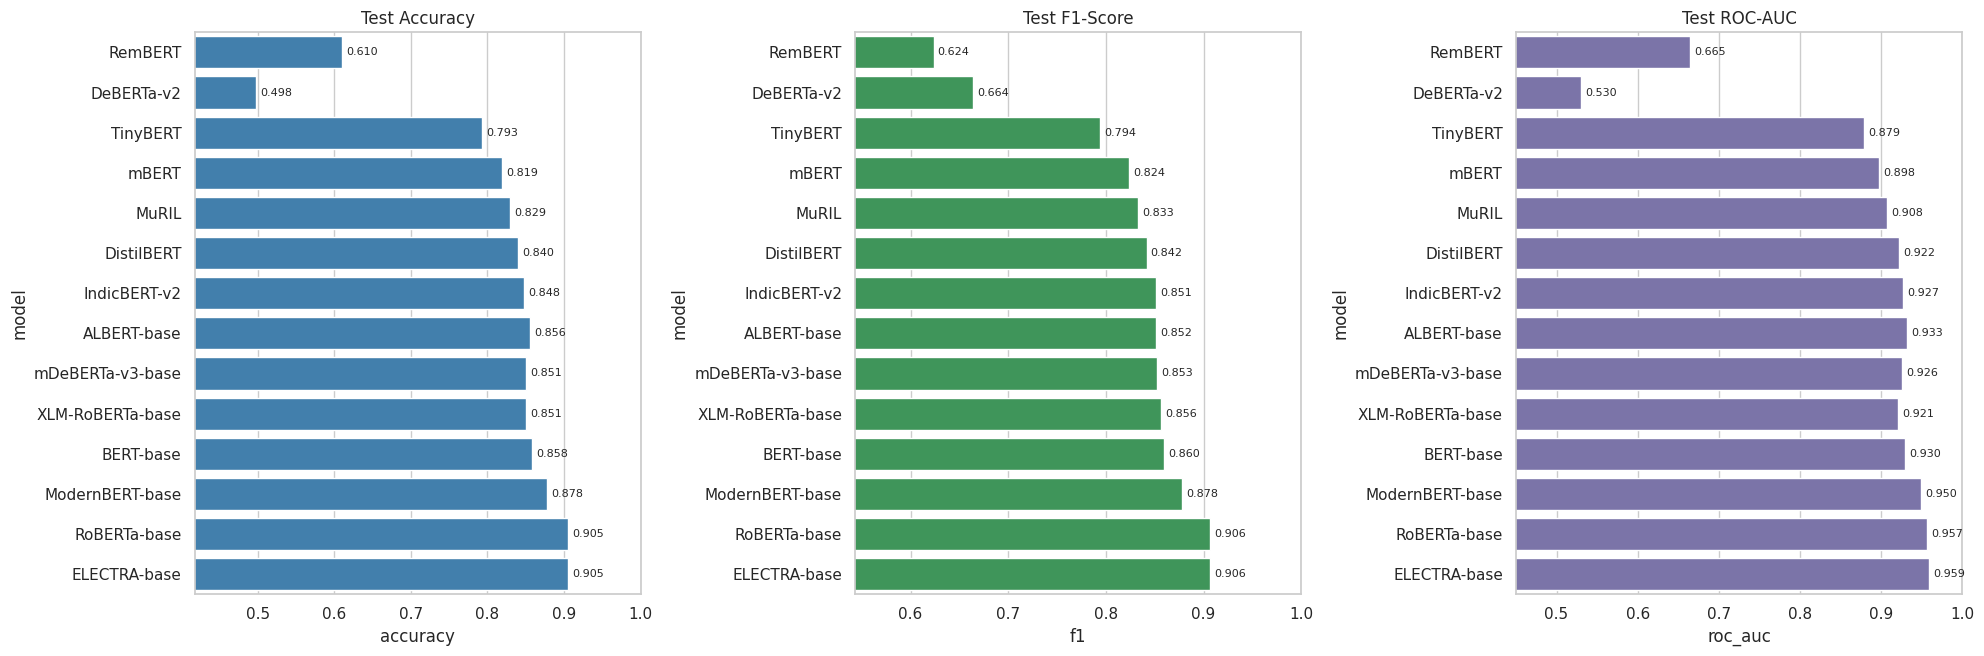

In [16]:
plot_df = results_df.sort_values("f1", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(plot_df) * 0.48)))
for axis, metric, title, color in [
    (axes[0], "accuracy", "Test Accuracy", "#3182bd"),
    (axes[1], "f1", "Test F1-Score", "#31a354"),
    (axes[2], "roc_auc", "Test ROC-AUC", "#756bb1"),
]:
    sns.barplot(data=plot_df, y="model", x=metric, color=color, ax=axis)
    axis.set_title(title)
    axis.set_xlim(max(0, plot_df[metric].min() - 0.08), 1.0)
    for container in axis.containers:
        axis.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()


**Code explanation:** Creates efficiency scatter plots: F1 versus runtime and F1 versus parameter count. Bubble size and labels help compare predictive performance against computational cost.


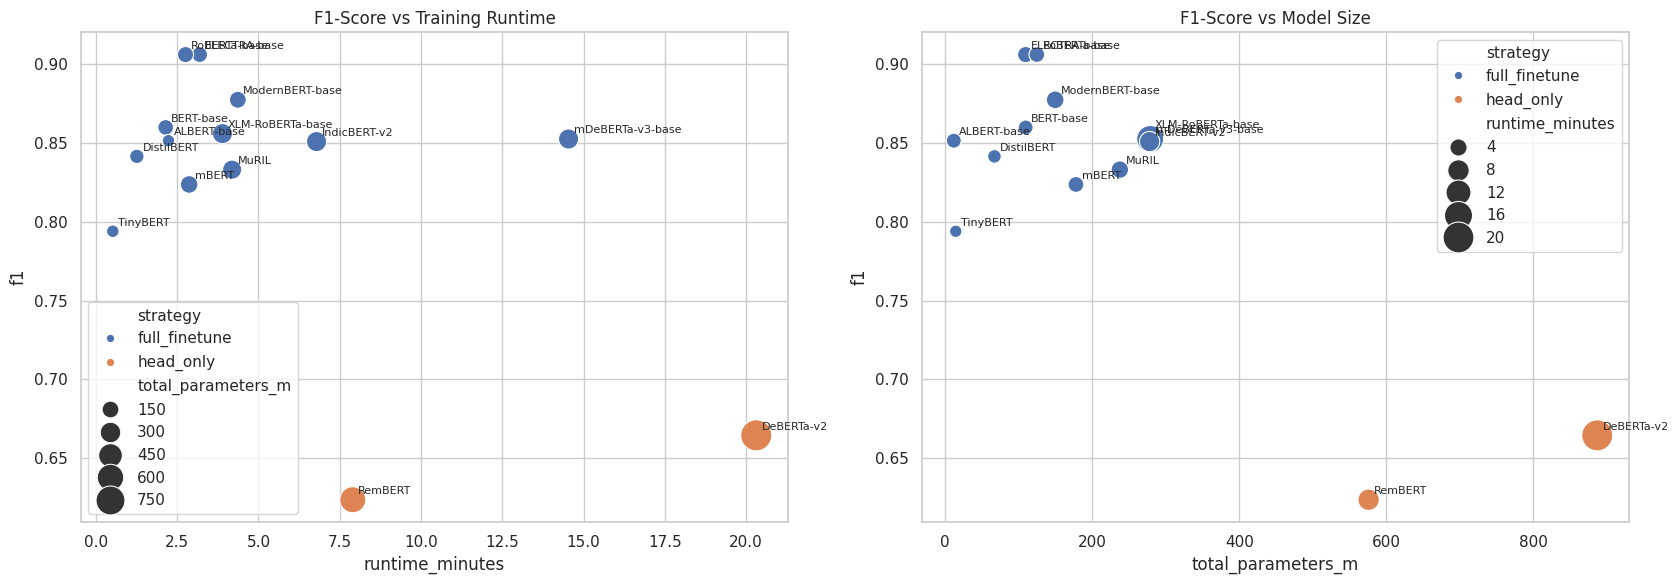

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.scatterplot(
    data=results_df,
    x="runtime_minutes",
    y="f1",
    hue="strategy",
    size="total_parameters_m",
    sizes=(80, 500),
    ax=axes[0],
)
for _, row in results_df.iterrows():
    axes[0].annotate(row["model"], (row["runtime_minutes"], row["f1"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[0].set_title("F1-Score vs Training Runtime")

sns.scatterplot(
    data=results_df,
    x="total_parameters_m",
    y="f1",
    hue="strategy",
    size="runtime_minutes",
    sizes=(80, 500),
    ax=axes[1],
)
for _, row in results_df.iterrows():
    axes[1].annotate(row["model"], (row["total_parameters_m"], row["f1"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("F1-Score vs Model Size")

plt.tight_layout()
plt.show()


### 15.1 — All classification metrics in one graph

This grouped chart makes precision–recall trade-offs visible instead of judging models using accuracy alone.


**Code explanation:** Reshapes accuracy, precision, recall, F1 and ROC-AUC into long format and displays them together in one grouped bar chart for a complete metric comparison.


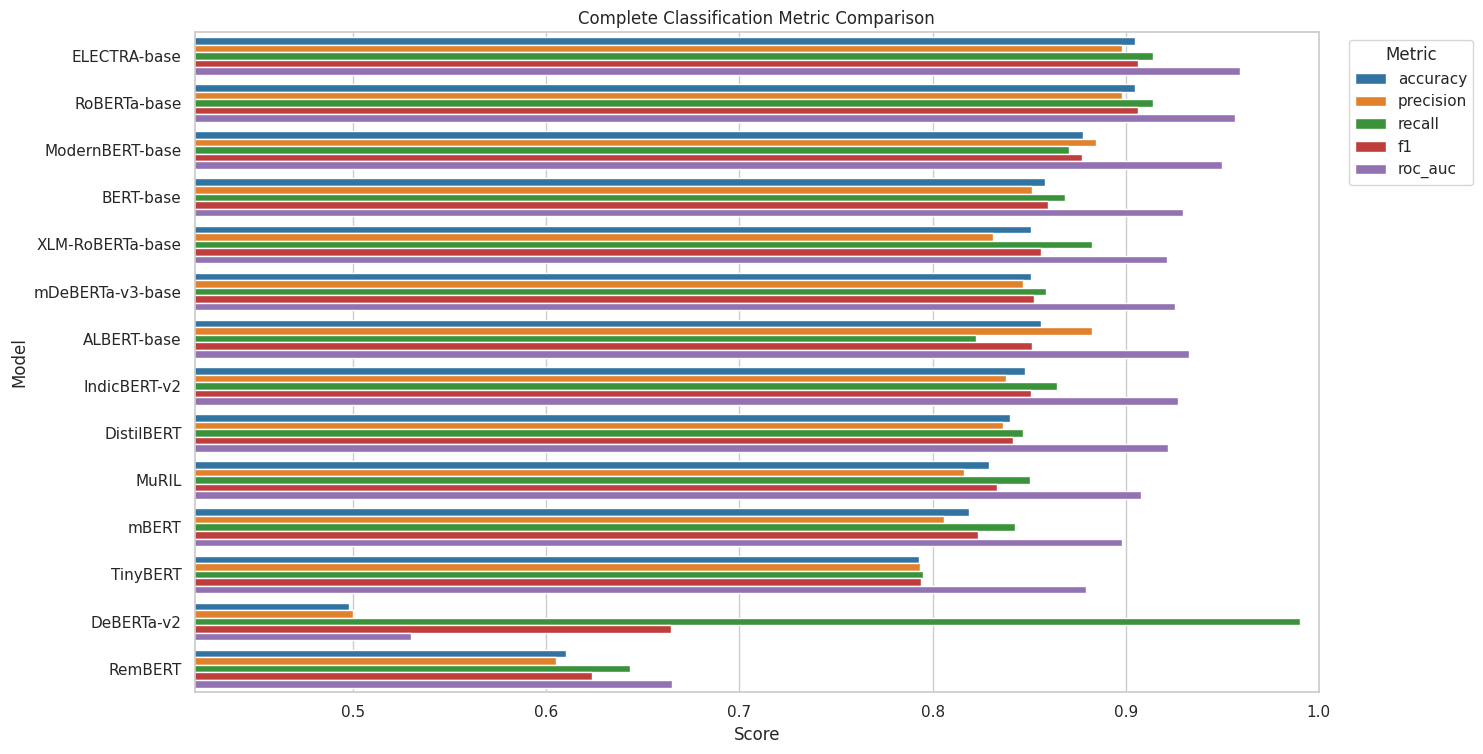

In [18]:
metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metrics_long = results_df.melt(
    id_vars="model",
    value_vars=metric_columns,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(15, max(7, len(results_df) * 0.55)))
sns.barplot(data=metrics_long, y="model", x="score", hue="metric", palette="tab10")
plt.title("Complete Classification Metric Comparison")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(max(0, metrics_long["score"].min() - 0.08), 1.0)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 15.2 — Test loss and training runtime


**Code explanation:** Compares test loss and training runtime. Lower test loss indicates better probability-based predictions, while lower runtime indicates faster training under the recorded hardware and settings.


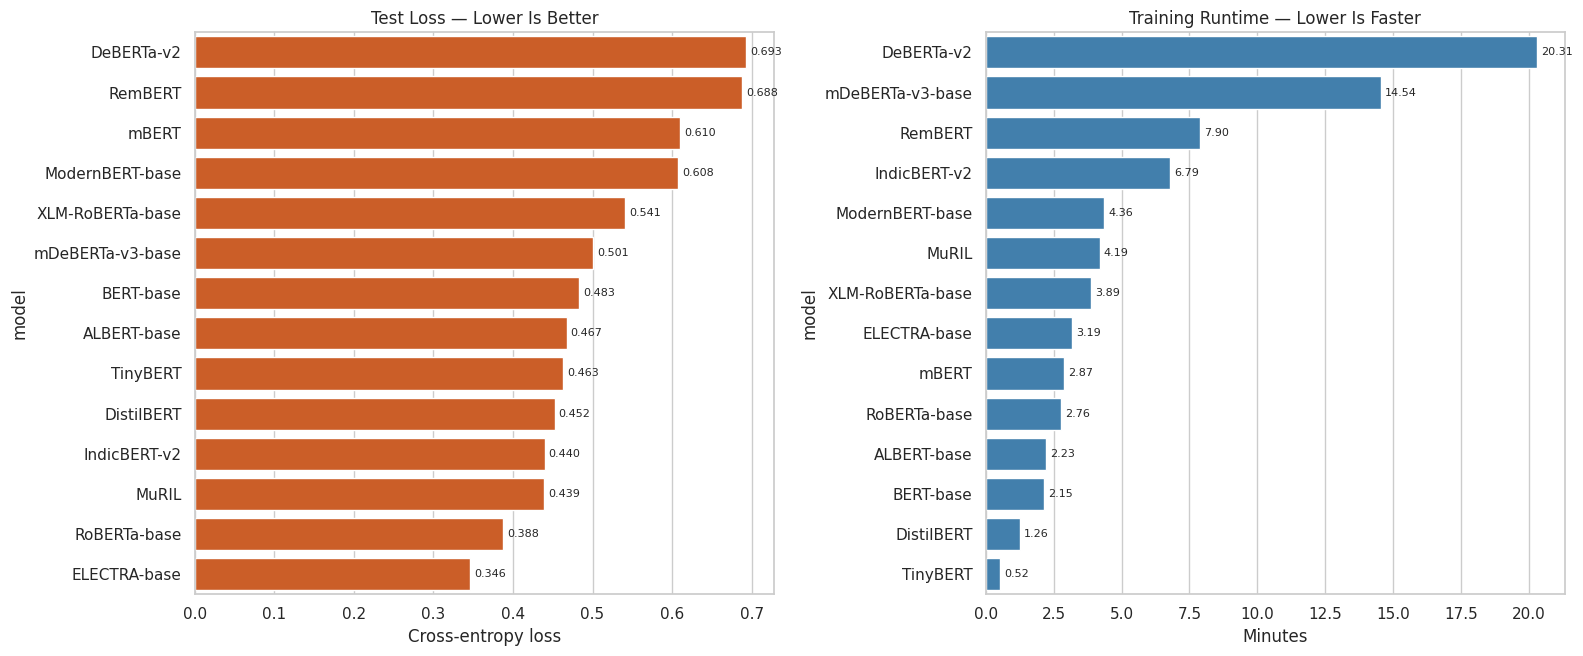

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(results_df) * 0.48)))

loss_df = results_df.sort_values("test_loss", ascending=False)
sns.barplot(data=loss_df, y="model", x="test_loss", color="#e6550d", ax=axes[0])
axes[0].set_title("Test Loss — Lower Is Better")
axes[0].set_xlabel("Cross-entropy loss")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3, fontsize=8)

runtime_df = results_df.sort_values("runtime_minutes", ascending=False)
sns.barplot(data=runtime_df, y="model", x="runtime_minutes", color="#3182bd", ax=axes[1])
axes[1].set_title("Training Runtime — Lower Is Faster")
axes[1].set_xlabel("Minutes")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()


### 15.3 — Total and trainable parameter comparison


**Code explanation:** Compares total and trainable parameters on a logarithmic scale. The distinction is especially important for head-only models, whose encoders are frozen even though their total parameter counts are large.


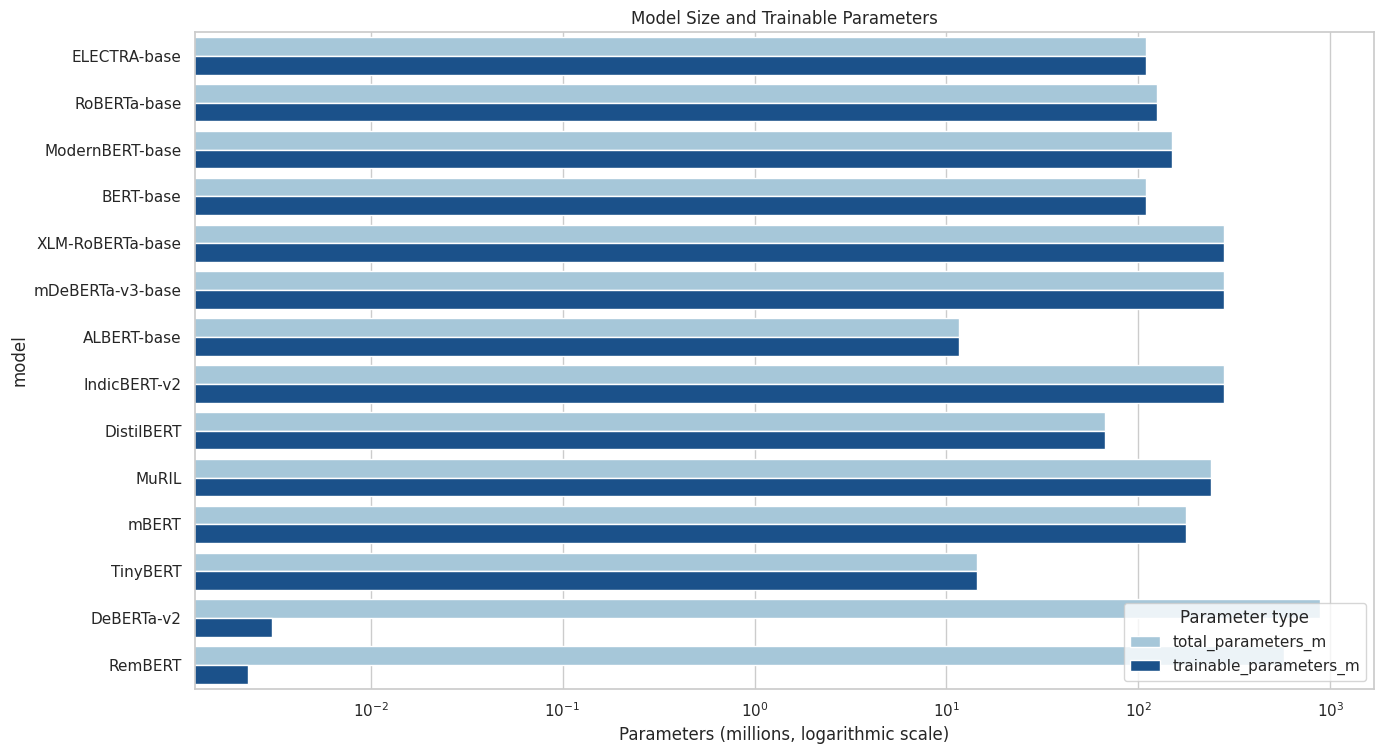

In [20]:
parameter_long = results_df.melt(
    id_vars="model",
    value_vars=["total_parameters_m", "trainable_parameters_m"],
    var_name="parameter_type",
    value_name="parameters_millions",
)

plt.figure(figsize=(14, max(7, len(results_df) * 0.55)))
sns.barplot(
    data=parameter_long,
    y="model",
    x="parameters_millions",
    hue="parameter_type",
    palette=["#9ecae1", "#08519c"],
)
plt.title("Model Size and Trainable Parameters")
plt.xlabel("Parameters (millions, logarithmic scale)")
plt.xscale("log")
plt.legend(title="Parameter type")
plt.tight_layout()
plt.show()


### 15.4 — Performance heatmap


**Code explanation:** Creates an annotated heatmap of all major classification metrics. Darker cells reveal strong scores and make model-level strengths or weaknesses easy to scan.


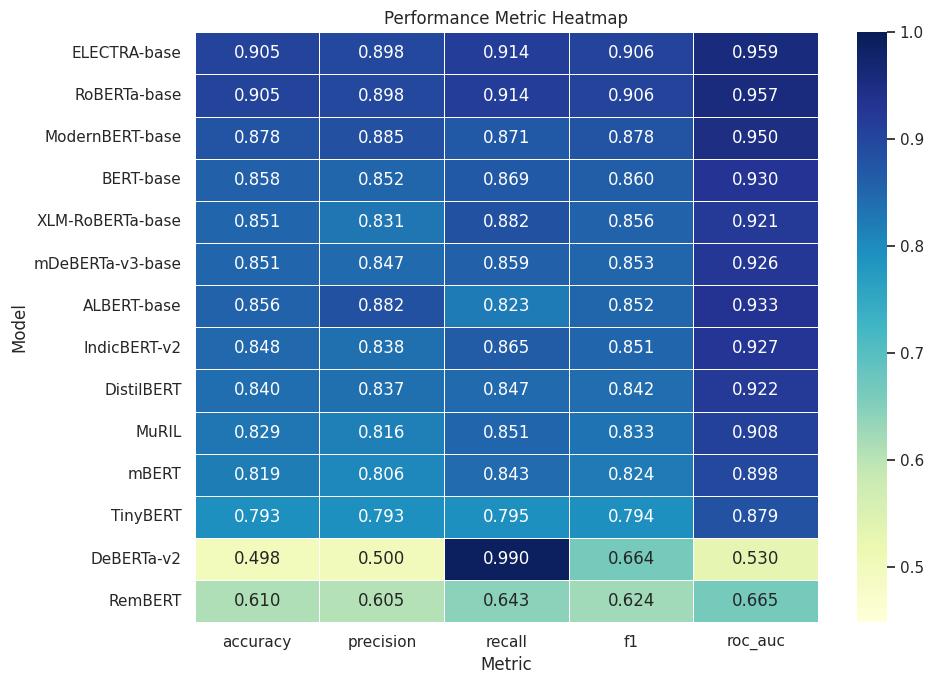

In [21]:
heatmap_data = results_df.set_index("model")[
    ["accuracy", "precision", "recall", "f1", "roc_auc"]
]

plt.figure(figsize=(10, max(6, len(results_df) * 0.5)))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=max(0, heatmap_data.min().min() - 0.05),
    vmax=1.0,
    linewidths=0.5,
)
plt.title("Performance Metric Heatmap")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


### 15.5 — Precision–recall balance


**Code explanation:** Plots precision against recall, with F1 controlling bubble size and colour. Models near the upper-right corner achieve a better balance between false positives and false negatives.


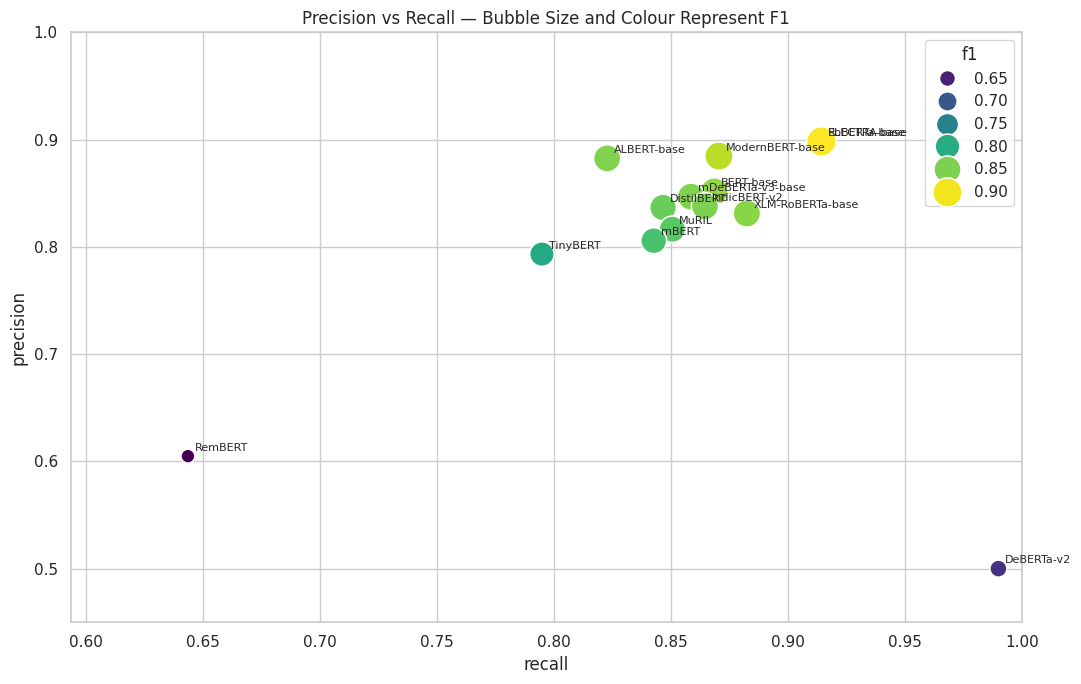

In [22]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=results_df,
    x="recall",
    y="precision",
    hue="f1",
    size="f1",
    sizes=(100, 450),
    palette="viridis",
)
for _, row in results_df.iterrows():
    plt.annotate(row["model"], (row["recall"], row["precision"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
plt.title("Precision vs Recall — Bubble Size and Colour Represent F1")
plt.xlim(max(0, results_df["recall"].min() - 0.05), 1.0)
plt.ylim(max(0, results_df["precision"].min() - 0.05), 1.0)
plt.tight_layout()
plt.show()


## Step 16 — Review incorrect predictions from any completed model


**Code explanation:** Selects the highest-ranked completed model and displays its most confident mistakes. Error analysis reveals difficult examples such as sarcasm, mixed sentiment and reviews requiring long context.


In [23]:
# Change this to any model present in all_predictions.
MODEL_FOR_ERROR_ANALYSIS = results_df.iloc[0]["model"]

prediction_data = all_predictions[MODEL_FOR_ERROR_ANALYSIS]
error_df = active_test_df[["clean_review", "label"]].copy().reset_index(drop=True)
error_df["prediction"] = prediction_data["predictions"]
error_df["positive_probability"] = prediction_data["positive_probability"]
error_df = error_df[error_df["label"] != error_df["prediction"]].copy()
error_df["true_sentiment"] = error_df["label"].map(ID2LABEL)
error_df["predicted_sentiment"] = error_df["prediction"].map(ID2LABEL)
error_df["confidence"] = np.where(
    error_df["prediction"] == 1,
    error_df["positive_probability"],
    1 - error_df["positive_probability"],
)

print("Model:", MODEL_FOR_ERROR_ANALYSIS)
print("Incorrect predictions:", len(error_df))
display(
    error_df.sort_values("confidence", ascending=False)[
        ["clean_review", "true_sentiment", "predicted_sentiment", "confidence"]
    ].head(20)
)


Model: ELECTRA-base
Incorrect predictions: 95


,clean_review,true_sentiment,predicted_sentiment,confidence
614,"Jack Frost 2, is probably the most cheesiest m...",POSITIVE,NEGATIVE,0.995462
171,Hrm-I think that line was from the old movie p...,POSITIVE,NEGATIVE,0.995027
611,"This short was in part four of the ""Short Cine...",POSITIVE,NEGATIVE,0.994434
55,"I must say, I thought I had seen it all. I am ...",POSITIVE,NEGATIVE,0.994008
399,Opera (the U.S. title is terror at the opera) ...,POSITIVE,NEGATIVE,0.992988
335,I watched the Pie-lette last night and the wor...,POSITIVE,NEGATIVE,0.992823
525,When i finally had the opportunity to watch Zo...,NEGATIVE,POSITIVE,0.992809
860,"Like most other people, I saw this movie on ""M...",NEGATIVE,POSITIVE,0.992467
533,You know I only watched 15 minutes of this fil...,NEGATIVE,POSITIVE,0.992452
12,"This could have been a very good film, if I ha...",NEGATIVE,POSITIVE,0.992393


## Step 17 — Package and download the best model for deployment

The winning model folder contains its weights, tokenizer, configuration, label mapping, metrics, requirements file and a minimal inference script. The following cell compresses the complete folder and starts a browser download in Google Colab.

> The ZIP can be several hundred megabytes. Keep the Colab tab open until the browser download begins.


**Code explanation:** Reads the saved winner's metadata, packages its weights, tokenizer, configuration and deployment files into one ZIP archive, then starts a browser download when running in Colab.


In [24]:
if not BEST_MODEL_DIR.exists():
    raise FileNotFoundError(
        "The best-model folder does not exist. Run the training cell with SAVE_BEST_MODEL=True first."
    )

metadata_path = BEST_MODEL_DIR / "deployment_metadata.json"
with open(metadata_path, encoding="utf-8") as file:
    deployment_metadata = json.load(file)

print("Deployment model:", deployment_metadata["model_name"])
print("Source checkpoint:", deployment_metadata["source_checkpoint"])
print("F1-score:", round(deployment_metadata["f1"], 4))
print("ROC-AUC:", round(deployment_metadata["roc_auc"], 4))
print("Files:", sorted(path.name for path in BEST_MODEL_DIR.iterdir()))

archive_base = OUTPUT_ROOT / f"{deployment_metadata['model_name'].replace(' ', '_')}_IMDb_deployment"
archive_path = Path(
    shutil.make_archive(
        base_name=str(archive_base),
        format="zip",
        root_dir=str(BEST_MODEL_DIR),
    )
)

print("ZIP created:", archive_path.resolve())
print("ZIP size (MB):", round(archive_path.stat().st_size / (1024 ** 2), 2))

try:
    from google.colab import files
    files.download(str(archive_path))
except ImportError:
    print("Outside Colab: download the ZIP from the notebook file browser:", archive_path)


Deployment model: ELECTRA-base
Source checkpoint: google/electra-base-discriminator
F1-score: 0.9062
ROC-AUC: 0.959
Files: ['config.json', 'deployment_example.py', 'deployment_metadata.json', 'model.safetensors', 'requirements.txt', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']
ZIP created: /content/imdb_bert_results/ELECTRA-base_IMDb_deployment.zip
ZIP size (MB): 387.83


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 18 — Test the saved deployment model

This reloads the winner from disk—the same files placed in the ZIP—and tests two new reviews.


**Code explanation:** Reloads the saved deployment folder instead of using the in-memory training model. Successful predictions here confirm that the ZIP contains the files required for later inference.


In [25]:
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=str(BEST_MODEL_DIR),
    tokenizer=str(BEST_MODEL_DIR),
    device=device,
    truncation=True,
    max_length=MAX_LENGTH,
)

new_reviews = [
    "The acting was excellent and the story kept me interested until the end.",
    "This movie was painfully slow, predictable, and not worth watching.",
]

deployment_predictions = sentiment_pipeline(new_reviews)
display(pd.DataFrame({"review": new_reviews, "prediction": deployment_predictions}))


Device set to use cuda:0


,review,prediction
0,The acting was excellent and the story kept me...,"{'label': 'POSITIVE', 'score': 0.9919716119766..."
1,"This movie was painfully slow, predictable, an...","{'label': 'NEGATIVE', 'score': 0.9942575693130..."


## How to interpret the experiment

- **Accuracy**: fraction of all reviews classified correctly.
- **Precision**: among reviews predicted positive, how many were actually positive.
- **Recall**: among all truly positive reviews, how many the model found.
- **F1-score**: harmonic mean of precision and recall; the primary ranking metric here.
- **ROC-AUC**: ability to rank positive reviews above negative reviews across different thresholds.
- **Test loss**: the model's average classification error; lower is better.
- **Confusion matrix**: counts of correct and incorrect predictions for each class.

## Fair-comparison checklist

For a research-quality comparison, use the same:

- cleaned dataset and split
- random seed
- maximum sequence length
- number of epochs
- learning rate
- evaluation metrics
- training strategy

RemBERT and DeBERTa-v2 `head_only` results must be discussed separately from `full_finetune` results. Run the full experiment several times with different seeds and report mean ± standard deviation if this becomes a paper or formal project.

## Deployment guidance

The quick-mode winner is suitable for testing the deployment pipeline. Before a final production deployment, rerun the strongest models using `RUN_MODE = "full"`, then download the newly selected winner. Keep `config.json`, tokenizer files and `model.safetensors` together; the ZIP already preserves this structure.

## Useful next experiments

1. Compare `MAX_LENGTH = 128`, `256`, and `512`.
2. Train on English, Hindi and Bengali reviews to test multilingual models properly.
3. Add macro-F1 for multilingual or imbalanced datasets.
4. Use PEFT/LoRA for RemBERT and DeBERTa-v2 on limited GPUs.
5. Perform hyperparameter tuning only after establishing this baseline.

## References

- [IMDb Dataset of 50K Movie Reviews on Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)
- [Hugging Face text-classification guide](https://huggingface.co/docs/transformers/tasks/sequence_classification)
- [IndicBERT v2 model card](https://huggingface.co/ai4bharat/IndicBERTv2-MLM-only)
- [MuRIL model card](https://huggingface.co/google/muril-base-cased)
- [ModernBERT-base model card](https://huggingface.co/answerdotai/ModernBERT-base)


## Why did ELECTRA-base give the highest accuracy in this experiment?

In the completed quick-mode run, ELECTRA-base produced **90.5% accuracy**, **0.9062 F1-score**, **0.9590 ROC-AUC**, and **0.3464 test loss**. RoBERTa-base matched its displayed accuracy and F1-score, but ELECTRA had the higher ROC-AUC, lower loss, shorter runtime, and fewer parameters. Therefore, ELECTRA was the strongest overall model under the ranking rule used in this notebook.

### 1. ELECTRA learns from every token during pretraining

Traditional BERT hides approximately 15% of the input tokens and learns mainly by predicting those masked tokens. ELECTRA instead replaces some tokens using a small generator and trains a discriminator to decide whether **every token** is original or replaced. This supplies a learning signal at many more token positions, making pretraining more sample-efficient.

### 2. Its discriminator objective fits sentiment classification well

Movie-review sentiment depends on detecting subtle word choices and contextual inconsistencies such as *excellent acting but a terrible story*. Replaced-token detection encourages ELECTRA to build detailed contextual representations, which can transfer effectively to positive-versus-negative classification.

### 3. It offers a strong capacity–efficiency balance

ELECTRA-base used about **109.48 million parameters**, compared with about **124.65 million** for RoBERTa-base and **149.61 million** for ModernBERT-base in this run. Its capacity was large enough for the task without being unnecessarily heavy, and it finished in roughly **2.91 minutes** in the reported experiment.

### 4. The experiment settings suited ELECTRA

The quick experiment used 4,000 training reviews, three epochs, a maximum length of 128 tokens, a fixed seed, and one shared learning rate. ELECTRA happened to adapt particularly well under these settings. Different seeds, sequence lengths, epochs, learning rates, or the full 50,000-review dataset could change the ranking.

### Correct conclusion to report

> Under the quick-mode IMDb experimental configuration, ELECTRA-base achieved the best overall combination of classification performance and computational efficiency. Its replaced-token-detection pretraining objective likely helped it learn strong contextual features efficiently. However, the result does not prove that ELECTRA is universally superior; repeated full-data experiments are required before making a general claim.

The architectural explanation above follows the original [ELECTRA research paper](https://arxiv.org/abs/2003.10555), which reports that replaced-token detection is more sample-efficient because the learning task is defined over all input tokens rather than only masked positions.
